# Cardiovascular Risk Score — Complete Analysis Notebook

MSIN0097 | UCL MSc Business Analytics | Machine Learning Coursework

Covers Steps 1–5: Problem Framing → EDA → Preprocessing → Model Exploration → Tuning & Evaluation

## Step 1: Problem Framing

**Dataset:** Cardiovascular Risk Dataset — 5,500 patient records, 15 features  
**Task:** Regression on `heart_disease_risk_score` (continuous, 0–100)  
**Secondary evaluation:** Derived classification (Low/Medium/High) via confirmed thresholds — 0–24.9, 25–54.9, 55–100 — applied post-prediction  

**Key decision:** `risk_category` dropped entirely — confirmed to be a direct algorithmic bucketing of the target score, not a clinically validated label. Including it would be perfect leakage.

**Metrics:** MAE (headline), RMSE, R², Macro F1 + High-recall on derived labels, error stratified by risk band  
**Limitation:** `heart_disease_risk_score` is not a clinically validated outcome (e.g. Framingham, SCORE2) — model predicts a synthetic score, not confirmed disease risk

## Step 2: Exploratory Data Analysis

**Objective:** Understand the data before touching a model — distributions, relationships, quality issues, and anything that could cause problems downstream.

**Target:** `heart_disease_risk_score` (continuous, 0–100) | `risk_category` dropped — confirmed leakage  
**Dataset:** 5,500 records × 13 features (post-cleaning) | 11 numeric, 2 categorical  

**EDA covers:**
- Data quality audit — missingness, duplicates, data types
- Target distribution — skew, normality, implied class split at thresholds (25 / 55)
- Feature distributions — skew, outliers, IQR-based flagging
- Categorical profiling — `smoking_status`, `family_history_heart_disease` vs target
- Correlation analysis — Pearson r with target, full feature heatmap, multicollinearity (VIF)
- Scatter plots — linearity and heteroscedasticity checks for top predictors
- Boundary region analysis — patients within ±5 of classification thresholds

**Key findings:**
- Zero missing values — no imputation required
- Top predictors: `systolic_bp` (r=0.90), `cholesterol_mg_dl` (0.85), `diastolic_bp` (0.81)
- `alcohol_units_per_week` has 214 outliers (~3.9%) — Winsorise for linear models only
- Multicollinearity: `systolic_bp`/`diastolic_bp` and `daily_steps`/`physical_activity` pairs
- ~25% of patients sit within ±5 of a classification threshold — evaluate boundary vs. core separately

In [2]:
# ── All imports ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

import warnings
warnings.filterwarnings('ignore')

# ── Styling ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold'
})
PALETTE = '#2C6E91'
ACCENT  = '#E05C2A'
sns.set_style('whitegrid')

# ── Load data ─────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('cardiovascular_risk_dataset.csv')
df = df_raw.drop(columns=['risk_category', 'Patient_ID'])

TARGET       = 'heart_disease_risk_score'
NUM_FEATURES = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
CAT_FEATURES = df.select_dtypes(exclude='number').columns.tolist()
RANDOM_STATE = 42

print(f'Shape: {df.shape}')
print(f'Numeric features ({len(NUM_FEATURES)}): {NUM_FEATURES}')
print(f'Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}')
print('All imports loaded.')

Shape: (5500, 15)
Numeric features (12): ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'diet_quality_score', 'alcohol_units_per_week']
Categorical features (2): ['smoking_status', 'family_history_heart_disease']
All imports loaded.


### 1. Data Quality Check

In [3]:
missing = df.isnull().sum()
dupes = df.duplicated().sum()
print(f'Missing values: {missing.sum()} | Duplicate rows: {dupes}')
print(f'Shape: {df.shape}')
print('\nDtypes:')
print(df.dtypes)

Missing values: 0 | Duplicate rows: 0
Shape: (5500, 15)

Dtypes:
age                                   int64
bmi                                 float64
systolic_bp                           int64
diastolic_bp                          int64
cholesterol_mg_dl                     int64
resting_heart_rate                    int64
smoking_status                       object
daily_steps                           int64
stress_level                          int64
physical_activity_hours_per_week    float64
sleep_hours                         float64
family_history_heart_disease         object
diet_quality_score                    int64
alcohol_units_per_week              float64
heart_disease_risk_score            float64
dtype: object


**Interpretation:** Zero missing values, no duplicates. `Patient_ID` and `risk_category` dropped. No imputation required.

---

### 2. Target Variable Distribution

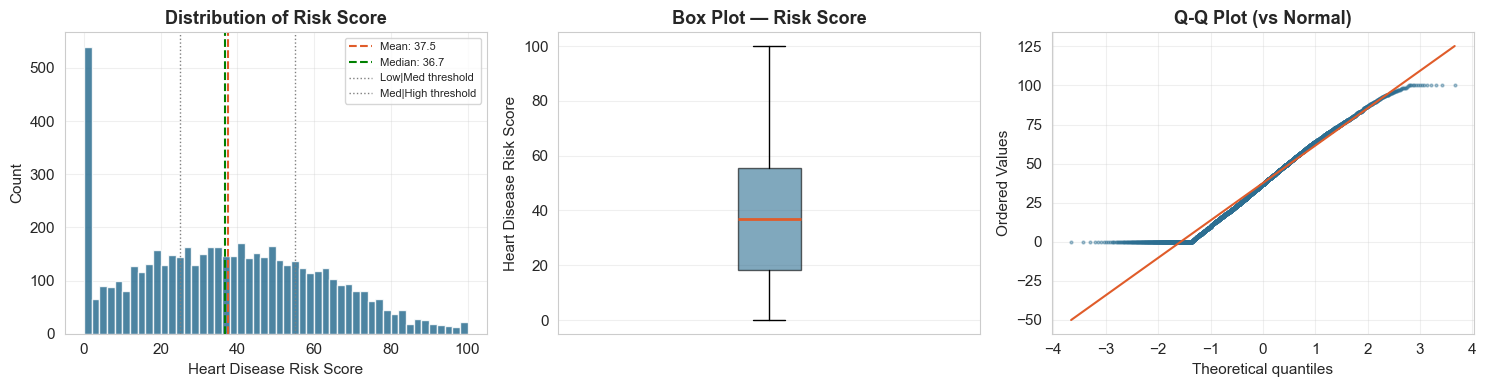

=== Target Descriptive Stats ===
Mean:         37.54
Median:       36.70
Std Dev:      24.29
Skewness:     0.212
Kurtosis:     -0.748
Min / Max:    0.0 / 100.0

=== Implied Class Distribution (derived thresholds) ===
heart_disease_risk_score
Low (0-24.9)        1838
Medium (25-54.9)    2244
High (55-100)       1403


In [4]:
target = df[TARGET]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(target, bins=50, color=PALETTE, edgecolor='white', alpha=0.85)
axes[0].axvline(target.mean(), color=ACCENT, linestyle='--', linewidth=1.5, label=f'Mean: {target.mean():.1f}')
axes[0].axvline(target.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {target.median():.1f}')
for thresh, lbl in [(25,'Low|Med'), (55,'Med|High')]:
    axes[0].axvline(thresh, color='grey', linestyle=':', linewidth=1, label=f'{lbl} threshold')
axes[0].set_title('Distribution of Risk Score')
axes[0].set_xlabel('Heart Disease Risk Score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

bp = axes[1].boxplot(target, vert=True, patch_artist=True,
                     boxprops=dict(facecolor=PALETTE, alpha=0.6),
                     medianprops=dict(color=ACCENT, linewidth=2))
axes[1].set_title('Box Plot — Risk Score')
axes[1].set_ylabel('Heart Disease Risk Score')
axes[1].set_xticks([])

stats.probplot(target, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (vs Normal)')
axes[2].get_lines()[0].set(color=PALETTE, markersize=2, alpha=0.4)
axes[2].get_lines()[1].set(color=ACCENT)

plt.tight_layout()
plt.show()

print('=== Target Descriptive Stats ===')
print(f'Mean:         {target.mean():.2f}')
print(f'Median:       {target.median():.2f}')
print(f'Std Dev:      {target.std():.2f}')
print(f'Skewness:     {target.skew():.3f}')
print(f'Kurtosis:     {target.kurtosis():.3f}')
print(f'Min / Max:    {target.min()} / {target.max()}')
print()
print('=== Implied Class Distribution (derived thresholds) ===')
bins = [0, 25, 55, 100]
labels = ['Low (0-24.9)', 'Medium (25-54.9)', 'High (55-100)']
bucketed = pd.cut(target, bins=bins, labels=labels, right=False)
print(bucketed.value_counts().sort_index().to_string())

**Interpretation:** Roughly uniform across 0–100, mild right skew (0.21). No target transformation needed for tree models. Implied class split ~33% Low / 41% Medium / 26% High — moderate imbalance.

---

### 3. Numeric Feature Distributions

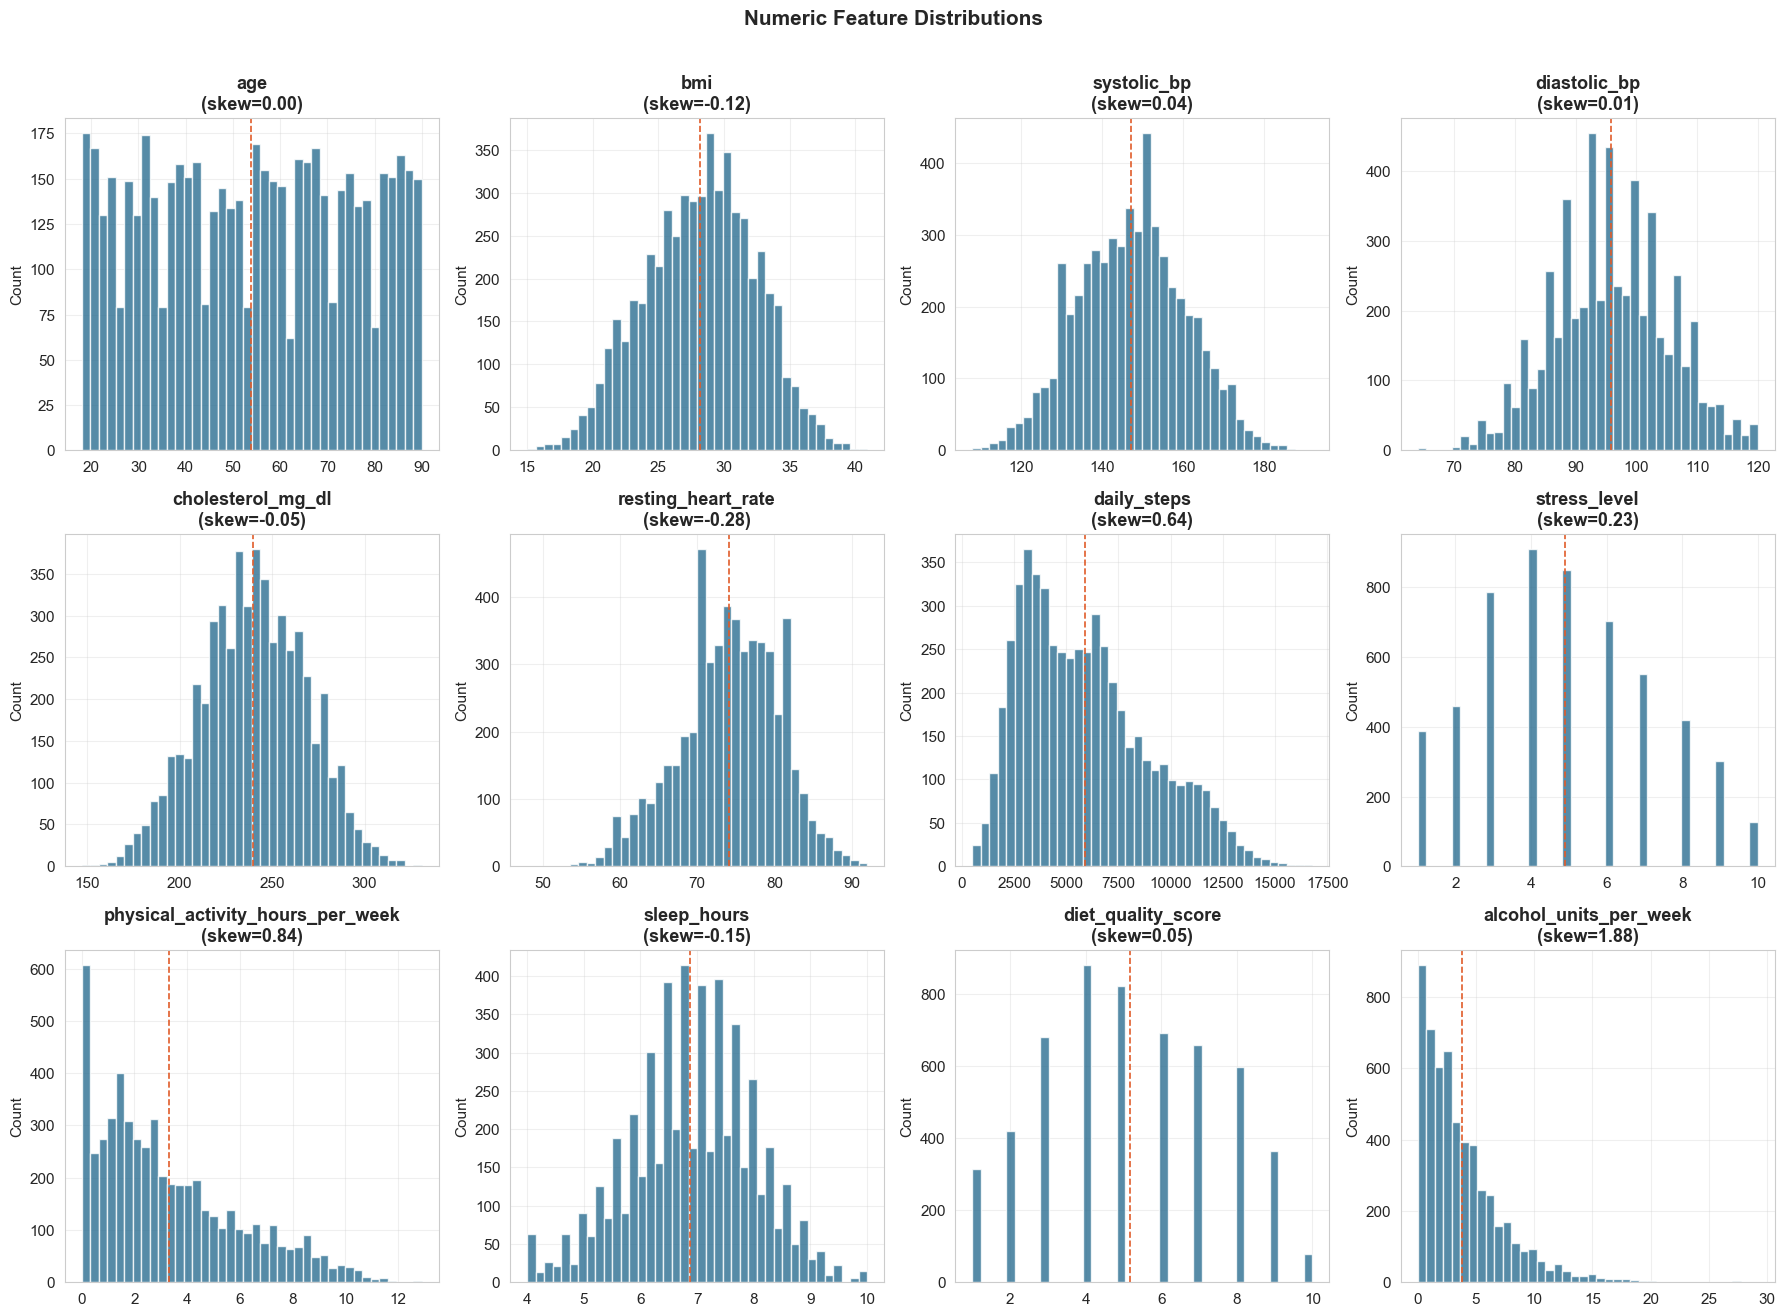

                                   count     mean      std    min     25%     50%     75%      max  skew  kurtosis
age                               5500.0    53.87    21.20   18.0    36.0    54.0    72.0     90.0  0.00     -1.20
bmi                               5500.0    28.17     4.19   15.0    25.2    28.4    31.1     40.9 -0.12     -0.39
systolic_bp                       5500.0   147.25    13.22  108.0   138.0   147.0   156.0    192.0  0.04     -0.35
diastolic_bp                      5500.0    95.76     9.45   64.0    89.0    96.0   102.0    120.0  0.01     -0.28
cholesterol_mg_dl                 5500.0   239.68    28.57  147.0   220.0   240.0   260.0    331.0 -0.05     -0.32
resting_heart_rate                5500.0    74.08     6.39   48.0    70.0    74.0    79.0     92.0 -0.28     -0.11
daily_steps                       5500.0  5902.93  3041.08  500.0  3428.0  5460.0  7772.0  16793.0  0.64     -0.32
stress_level                      5500.0     4.91     2.30    1.0     3.0     5.

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

for i, col in enumerate(NUM_FEATURES):
    ax = axes[i]
    ax.hist(df[col], bins=40, color=PALETTE, edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color=ACCENT, linestyle='--', linewidth=1.2, label='Mean')
    ax.set_title(f'{col}\n(skew={df[col].skew():.2f})')
    ax.set_ylabel('Count')

for j in range(len(NUM_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

summary = df[NUM_FEATURES].describe().T
summary['skew'] = df[NUM_FEATURES].skew().round(3)
summary['kurtosis'] = df[NUM_FEATURES].kurtosis().round(3)
print(summary.round(2).to_string())

**Interpretation:** `alcohol_units_per_week` right-skewed → Winsorise for linear models. Clinical features approximately normal. `stress_level` and `diet_quality_score` are ordinal integers.

---

### 4. Outlier Analysis

In [6]:
outlier_summary = []
for col in NUM_FEATURES + [TARGET]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'feature': col, 'lower_fence': round(lower,2),
        'upper_fence': round(upper,2), 'n_outliers': n_out,
        'pct_outliers': round(n_out/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_summary).set_index('feature')
print(outlier_df[outlier_df['n_outliers'] > 0].sort_values('n_outliers', ascending=False).to_string())

                                  lower_fence  upper_fence  n_outliers  pct_outliers
feature                                                                             
alcohol_units_per_week                  -4.95        11.45         214          3.89
sleep_hours                              4.10         9.70          81          1.47
physical_activity_hours_per_week        -4.35        10.45          42          0.76
daily_steps                          -3088.00     14288.00          21          0.38
resting_heart_rate                      56.50        92.50          17          0.31
systolic_bp                            111.00       183.00          15          0.27
bmi                                     16.35        39.95           9          0.16
cholesterol_mg_dl                      160.00       320.00           7          0.13
diastolic_bp                            69.50       121.50           5          0.09


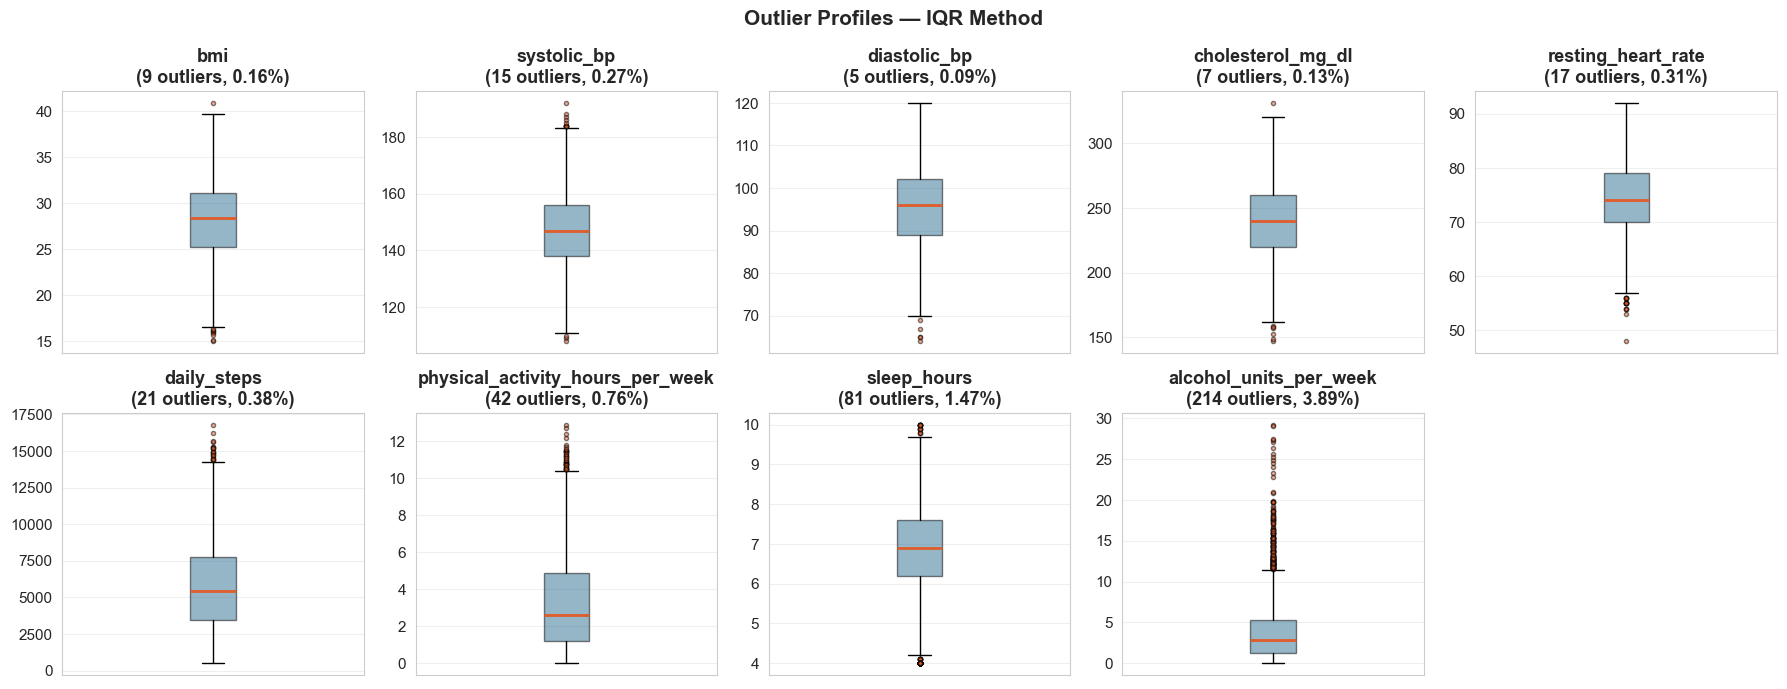

In [7]:
flagged_cols = [c for c in NUM_FEATURES if outlier_df.loc[c, 'n_outliers'] > 0]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(flagged_cols):
    ax = axes[i]
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=PALETTE, alpha=0.5),
               medianprops=dict(color=ACCENT, linewidth=2),
               flierprops=dict(marker='o', markerfacecolor=ACCENT, markersize=3, alpha=0.5))
    n = outlier_df.loc[col, 'n_outliers']
    ax.set_title(f'{col}\n({n} outliers, {outlier_df.loc[col,"pct_outliers"]}%)')
    ax.set_xticks([])

for j in range(len(flagged_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Profiles — IQR Method', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** `alcohol_units_per_week` 214 outliers (~3.9%) — real population, not errors. Winsorise at 99th percentile for linear models. Trees handle natively.

---

### 5. Categorical Feature Profiles

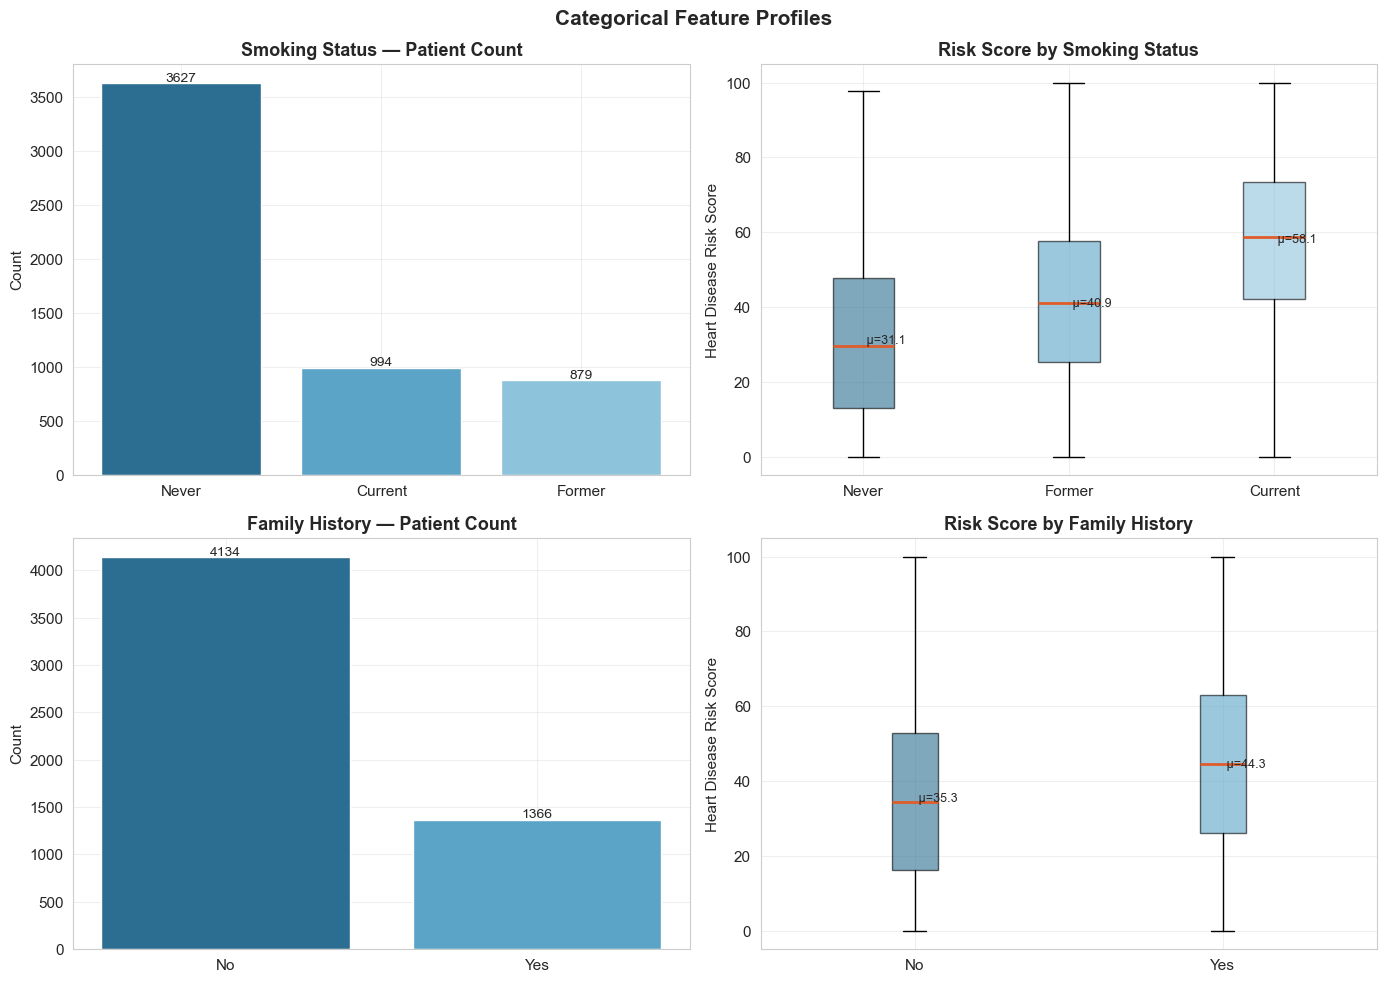

=== Smoking Status — One-Way ANOVA ===
F=596.00, p=0.0000 → Significant

=== Family History — Independent t-test ===
t=12.05, p=0.0000 → Significant


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

smoke_counts = df['smoking_status'].value_counts()
axes[0, 0].bar(smoke_counts.index, smoke_counts.values, color=[PALETTE, '#5BA4C7', '#8EC3DC'], edgecolor='white')
axes[0, 0].set_title('Smoking Status — Patient Count')
axes[0, 0].set_ylabel('Count')
for i, (idx, val) in enumerate(smoke_counts.items()):
    axes[0, 0].text(i, val + 20, str(val), ha='center', fontsize=10)

smoke_order = ['Never', 'Former', 'Current']
smoke_data = [df[df['smoking_status'] == s][TARGET].values for s in smoke_order]
bp = axes[0, 1].boxplot(smoke_data, labels=smoke_order, patch_artist=True,
                         medianprops=dict(color=ACCENT, linewidth=2))
for patch, color in zip(bp['boxes'], [PALETTE, '#5BA4C7', '#8EC3DC']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0, 1].set_title('Risk Score by Smoking Status')
axes[0, 1].set_ylabel('Heart Disease Risk Score')
for i, s in enumerate(smoke_order):
    m = df[df['smoking_status'] == s][TARGET].mean()
    axes[0, 1].text(i+1, m, f' μ={m:.1f}', va='center', fontsize=9)

fh_counts = df['family_history_heart_disease'].value_counts()
axes[1, 0].bar(fh_counts.index, fh_counts.values, color=[PALETTE, '#5BA4C7'], edgecolor='white')
axes[1, 0].set_title('Family History — Patient Count')
axes[1, 0].set_ylabel('Count')
for i, (idx, val) in enumerate(fh_counts.items()):
    axes[1, 0].text(i, val + 20, str(val), ha='center', fontsize=10)

fh_order = ['No', 'Yes']
fh_data = [df[df['family_history_heart_disease'] == s][TARGET].values for s in fh_order]
bp2 = axes[1, 1].boxplot(fh_data, labels=fh_order, patch_artist=True,
                           medianprops=dict(color=ACCENT, linewidth=2))
for patch, color in zip(bp2['boxes'], [PALETTE, '#5BA4C7']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1, 1].set_title('Risk Score by Family History')
axes[1, 1].set_ylabel('Heart Disease Risk Score')
for i, s in enumerate(fh_order):
    m = df[df['family_history_heart_disease'] == s][TARGET].mean()
    axes[1, 1].text(i+1, m, f' μ={m:.1f}', va='center', fontsize=9)

plt.suptitle('Categorical Feature Profiles', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Smoking Status — One-Way ANOVA ===')
f, p = stats.f_oneway(*[df[df['smoking_status'] == s][TARGET] for s in smoke_order])
print(f'F={f:.2f}, p={p:.4f} → {"Significant" if p < 0.05 else "Not significant"}')
print()
print('=== Family History — Independent t-test ===')
t, p2 = stats.ttest_ind(df[df['family_history_heart_disease']=='Yes'][TARGET],
                         df[df['family_history_heart_disease']=='No'][TARGET])
print(f't={t:.2f}, p={p2:.4f} → {"Significant" if p2 < 0.05 else "Not significant"}')

**Interpretation:** Both features statistically significant (ANOVA and t-test). Current smokers have higher median risk. Family history shows clear separation.

---

### 6. Correlation Analysis

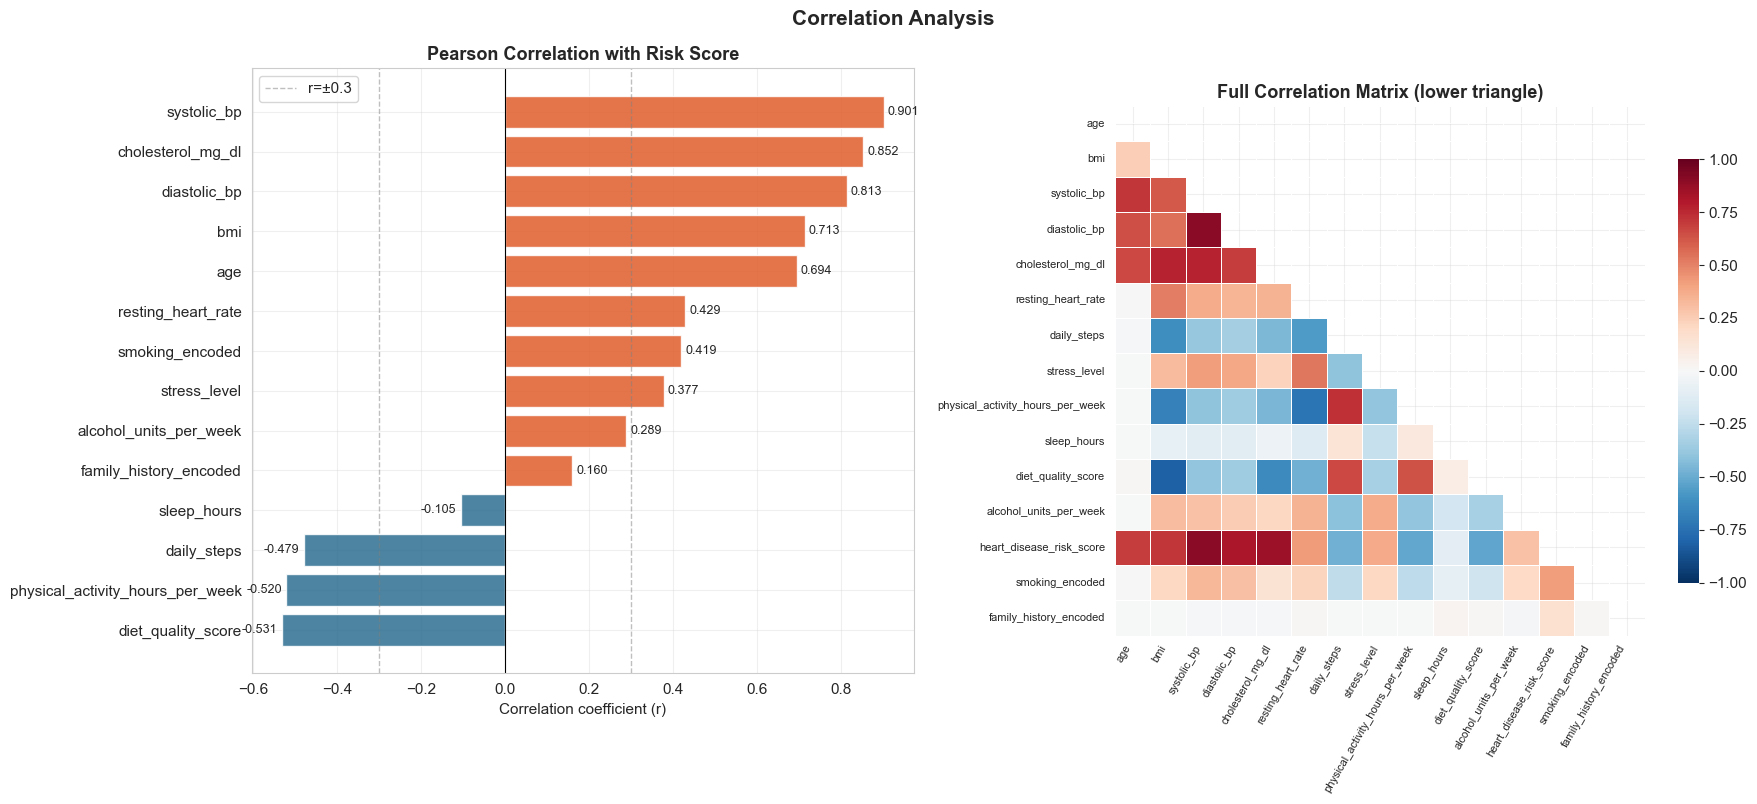

In [9]:
df_enc = df.copy()
df_enc['smoking_encoded'] = df_enc['smoking_status'].map({'Never': 0, 'Former': 1, 'Current': 2})
df_enc['family_history_encoded'] = df_enc['family_history_heart_disease'].map({'No': 0, 'Yes': 1})
df_enc = df_enc.drop(columns=['smoking_status', 'family_history_heart_disease'])

corr_target = df_enc.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # wider + taller

colors_bar = [ACCENT if v > 0 else PALETTE for v in corr_target.values]
axes[0].barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(0.3, color='grey', linestyle='--', linewidth=1, alpha=0.5, label='r=±0.3')
axes[0].axvline(-0.3, color='grey', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title('Pearson Correlation with Risk Score')
axes[0].set_xlabel('Correlation coefficient (r)')
axes[0].legend()
for i, (idx, val) in enumerate(corr_target.items()):
    axes[0].text(val + (0.01 if val >= 0 else -0.01), i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

corr_matrix = df_enc.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, square=True, vmin=-1, vmax=1, cbar_kws={'shrink': 0.7})
axes[1].set_title('Full Correlation Matrix (lower triangle)')

# ── FIX: rotate to 60°, right-align, smaller font — prevents stacking ──
axes[1].set_xticklabels(
    axes[1].get_xticklabels(),
    rotation=60, ha='right', fontsize=8
)
axes[1].set_yticklabels(
    axes[1].get_yticklabels(),
    rotation=0, fontsize=8
)
axes[1].tick_params(axis='x', pad=2)

plt.suptitle('Correlation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Top predictors: `systolic_bp` (r=0.90), `cholesterol_mg_dl` (0.85), `diastolic_bp` (0.81). Protective: `diet_quality_score` (-0.53), `physical_activity` (-0.52). Multicollinearity flag: bp pair and steps/activity pair.

---

### 7. Feature–Target Scatter Plots

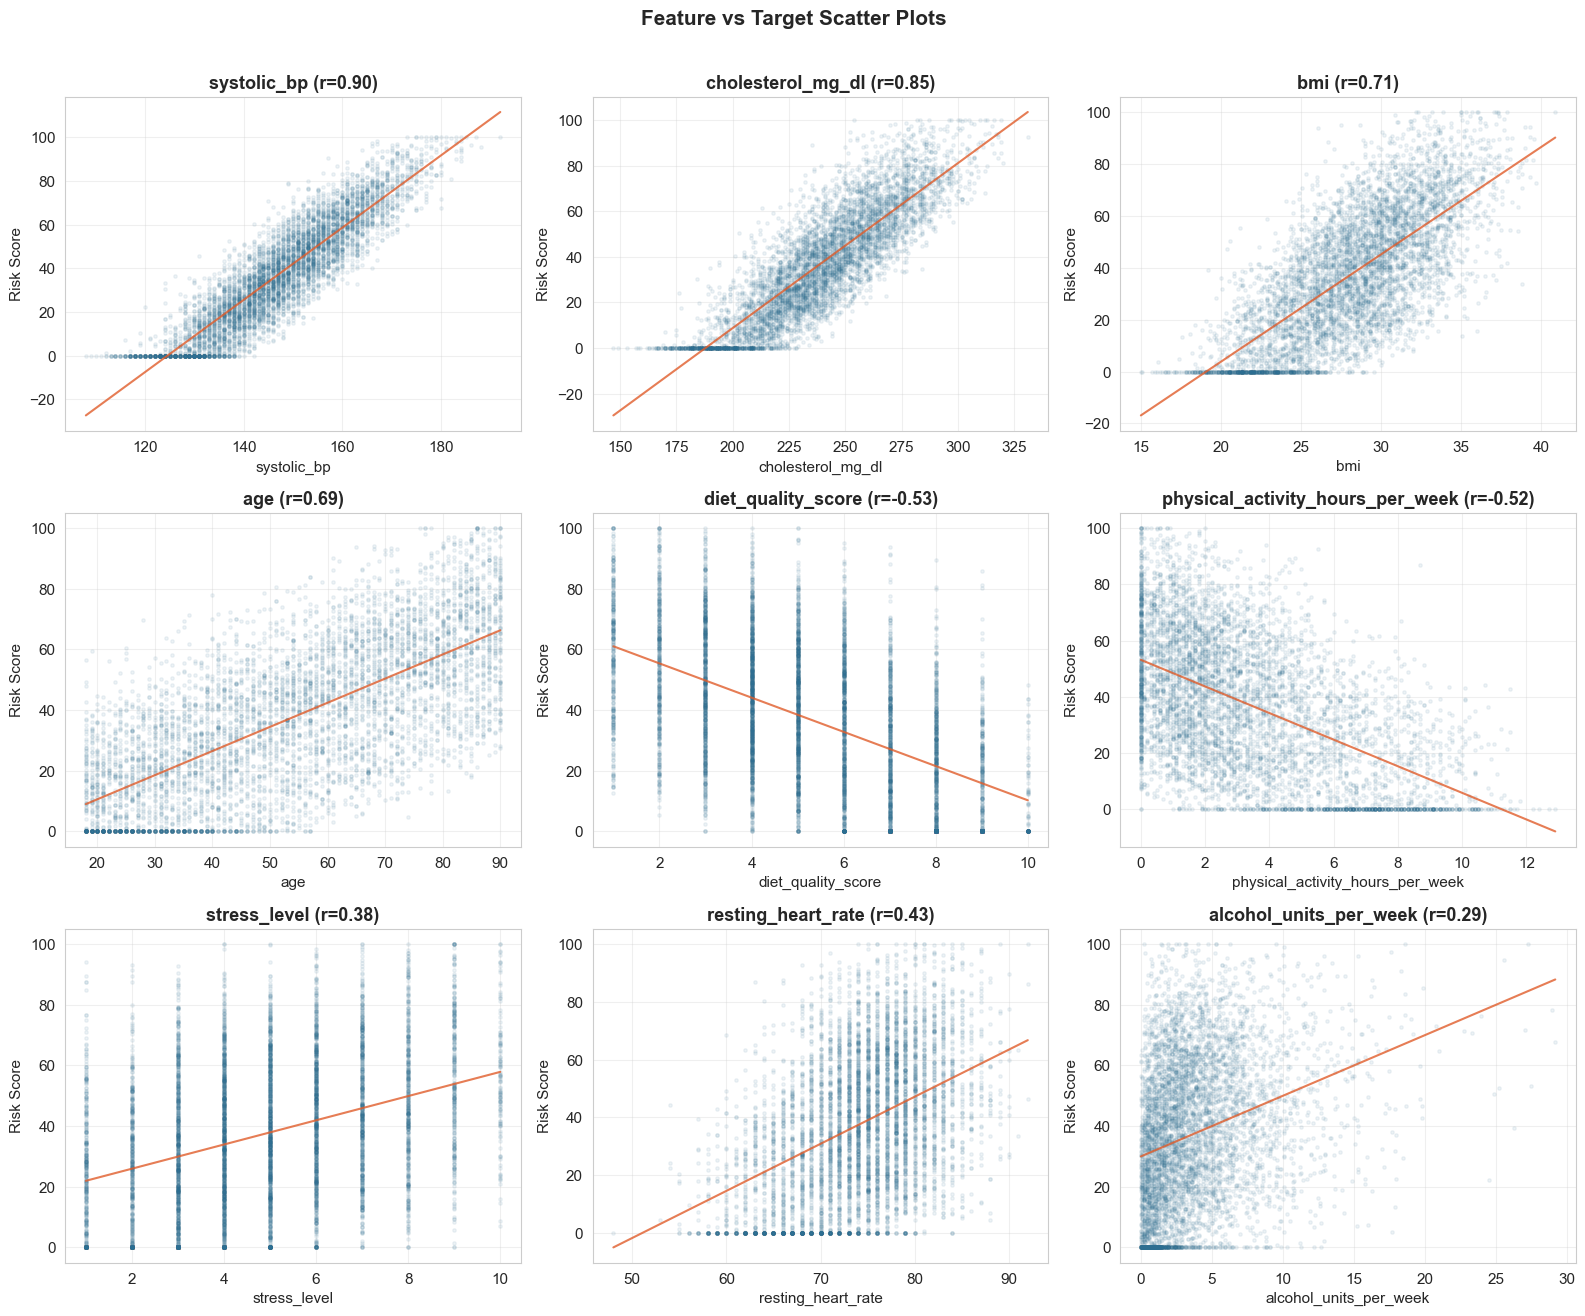

In [10]:
top_features = ['systolic_bp', 'cholesterol_mg_dl', 'bmi', 'age',
                'diet_quality_score', 'physical_activity_hours_per_week',
                'stress_level', 'resting_heart_rate', 'alcohol_units_per_week']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(top_features):
    ax = axes[i]
    ax.scatter(df[col], df[TARGET], alpha=0.08, s=6, color=PALETTE)
    from scipy.stats import pearsonr
    sorted_x = np.sort(df[col].values)
    r, _ = pearsonr(df[col], df[TARGET])
    z = np.polyfit(df[col], df[TARGET], 1)
    p_line = np.poly1d(z)
    ax.plot(sorted_x, p_line(sorted_x), color=ACCENT, linewidth=1.5, alpha=0.8)
    ax.set_xlabel(col)
    ax.set_ylabel('Risk Score')
    ax.set_title(f'{col} (r={r:.2f})')

plt.suptitle('Feature vs Target Scatter Plots', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Predominantly linear relationships for strong predictors. `alcohol_units_per_week` shows heteroscedasticity at high values.

---

### 8. Boundary Region Analysis

Patients within ±5 of threshold 25 (Low|Medium): 726 (13.2%)
Patients within ±5 of threshold 55 (Medium|High): 649 (11.8%)
Total boundary-region patients: 1375 (25.0%)


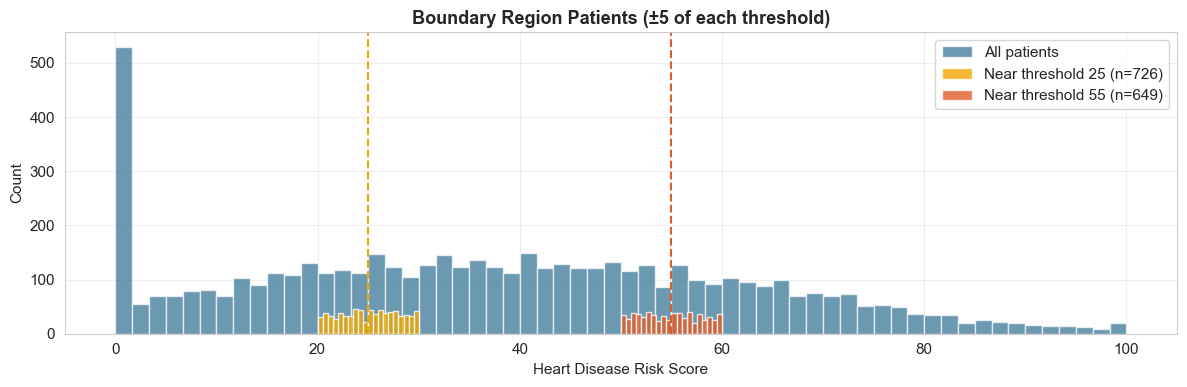

In [11]:
MARGIN = 5

near_25 = df[(df[TARGET] >= 25 - MARGIN) & (df[TARGET] <= 25 + MARGIN)]
near_55 = df[(df[TARGET] >= 55 - MARGIN) & (df[TARGET] <= 55 + MARGIN)]

print(f'Patients within ±{MARGIN} of threshold 25 (Low|Medium): {len(near_25)} ({len(near_25)/len(df)*100:.1f}%)')
print(f'Patients within ±{MARGIN} of threshold 55 (Medium|High): {len(near_55)} ({len(near_55)/len(df)*100:.1f}%)')
print(f'Total boundary-region patients: {len(near_25) + len(near_55)} ({(len(near_25)+len(near_55))/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df[TARGET], bins=60, color=PALETTE, edgecolor='white', alpha=0.7, label='All patients')
ax.hist(near_25[TARGET], bins=20, color='#F0A500', alpha=0.8, label=f'Near threshold 25 (n={len(near_25)})')
ax.hist(near_55[TARGET], bins=20, color=ACCENT, alpha=0.8, label=f'Near threshold 55 (n={len(near_55)})')
ax.axvline(25, color='#F0A500', linestyle='--', linewidth=1.5)
ax.axvline(55, color=ACCENT, linestyle='--', linewidth=1.5)
ax.set_xlabel('Heart Disease Risk Score')
ax.set_ylabel('Count')
ax.set_title(f'Boundary Region Patients (±{MARGIN} of each threshold)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** ~25% of patients near thresholds. A model with MAE 4–5 will regularly flip class labels near boundaries — structural property, not a model failure. Report boundary vs core classification separately.

---

---
# Step 3: Preprocessing Pipeline & Data Split

**Covers:**
1. Categorical encoding — ordinal `smoking_status`, binary `family_history`
2. Feature engineering — `age_bmi` interaction (r=0.838 with target)
3. Winsorisation of `alcohol_units_per_week` (linear pipeline only)
4. Stratified 70/15/15 train/val/test split
5. Two sklearn pipelines — linear (scaled) and tree (passthrough)
6. StratifiedKFold(5) CV setup
7. Leakage guard and readiness checks

### 1. Feature Groups

In [12]:
TARGET = 'heart_disease_risk_score'

ORDINAL_FEATURES = ['smoking_status']
BINARY_FEATURES  = ['family_history_heart_disease']

NUMERIC_FEATURES = [
    'age', 'bmi', 'systolic_bp', 'diastolic_bp',
    'cholesterol_mg_dl', 'resting_heart_rate',
    'daily_steps', 'stress_level',
    'physical_activity_hours_per_week', 'sleep_hours',
    'diet_quality_score'
]
SKEWED_FEATURE = ['alcohol_units_per_week']

ALL_FEATURES = NUMERIC_FEATURES + SKEWED_FEATURE + ORDINAL_FEATURES + BINARY_FEATURES

print(f'Numeric (standard):  {NUMERIC_FEATURES}')
print(f'Numeric (skewed):    {SKEWED_FEATURE}')
print(f'Ordinal categorical: {ORDINAL_FEATURES}')
print(f'Binary categorical:  {BINARY_FEATURES}')
print(f'Total features:      {len(ALL_FEATURES)}')

Numeric (standard):  ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'diet_quality_score']
Numeric (skewed):    ['alcohol_units_per_week']
Ordinal categorical: ['smoking_status']
Binary categorical:  ['family_history_heart_disease']
Total features:      14


### 2. Categorical Encoding

`smoking_status` → Ordinal (Never=0, Former=1, Current=2) — EDA confirmed risk increases monotonically.  
`family_history_heart_disease` → Binary (No=0, Yes=1).

In [13]:
df_encoded = df.copy()

SMOKING_ORDER = ['Never', 'Former', 'Current']
df_encoded['smoking_status'] = pd.Categorical(
    df_encoded['smoking_status'], categories=SMOKING_ORDER, ordered=True
).codes

df_encoded['family_history_heart_disease'] = (
    df_encoded['family_history_heart_disease'].map({'No': 0, 'Yes': 1})
)

print('Encoding applied:')
print(f'  smoking_status unique values:              {sorted(df_encoded["smoking_status"].unique())}')
print(f'  family_history_heart_disease unique values: {sorted(df_encoded["family_history_heart_disease"].unique())}')
print(f'\nEncoded df shape: {df_encoded.shape}')

Encoding applied:
  smoking_status unique values:              [0, 1, 2]
  family_history_heart_disease unique values: [0, 1]

Encoded df shape: (5500, 15)


### 3. Feature Engineering — `age_bmi` Interaction

`age` (r=0.69) × `bmi` (r=0.71) → r=0.838 with target. Clinically meaningful: risk of high BMI compounds with age. Included in tree pipeline only — VIF=61.3 makes it unsafe for linear models.

In [14]:
df_encoded['age_bmi'] = df_encoded['age'] * df_encoded['bmi']

r = df_encoded['age_bmi'].corr(df_encoded[TARGET])
print(f'age_bmi correlation with target: r = {r:.4f}')
print(f'age alone:  r = {df_encoded["age"].corr(df_encoded[TARGET]):.4f}')
print(f'bmi alone:  r = {df_encoded["bmi"].corr(df_encoded[TARGET]):.4f}')
print(f'\nage_bmi added. New shape: {df_encoded.shape}')

age_bmi correlation with target: r = 0.8383
age alone:  r = 0.6943
bmi alone:  r = 0.7131

age_bmi added. New shape: (5500, 16)


In [15]:
# Tree pipeline — 15 features including age_bmi
TREE_NUMERIC = [
    'age', 'bmi', 'systolic_bp', 'diastolic_bp',
    'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps',
    'stress_level', 'physical_activity_hours_per_week',
    'sleep_hours', 'diet_quality_score', 'age_bmi'
]

# Linear pipeline — age_bmi dropped (VIF=61.3), diastolic_bp dropped (VIF=5.6)
LINEAR_NUMERIC = [
    'age', 'bmi', 'systolic_bp',
    'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps',
    'stress_level', 'physical_activity_hours_per_week',
    'sleep_hours', 'diet_quality_score'
]

# SKEWED_FEATURE, ORDINAL_FEATURES, BINARY_FEATURES already defined in Cell 31 — not redefined here

ALL_TREE_FEATURES   = TREE_NUMERIC + SKEWED_FEATURE + ORDINAL_FEATURES + BINARY_FEATURES
ALL_LINEAR_FEATURES = LINEAR_NUMERIC + SKEWED_FEATURE + ORDINAL_FEATURES + BINARY_FEATURES

print(f'Tree pipeline features  ({len(ALL_TREE_FEATURES)}): {ALL_TREE_FEATURES}')
print(f'Linear pipeline features ({len(ALL_LINEAR_FEATURES)}): {ALL_LINEAR_FEATURES}')

Tree pipeline features  (15): ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'diet_quality_score', 'age_bmi', 'alcohol_units_per_week', 'smoking_status', 'family_history_heart_disease']
Linear pipeline features (13): ['age', 'bmi', 'systolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'diet_quality_score', 'alcohol_units_per_week', 'smoking_status', 'family_history_heart_disease']


### 4. VIF — Multicollinearity (Linear Pipeline Only)

In [16]:
!pip install statsmodels

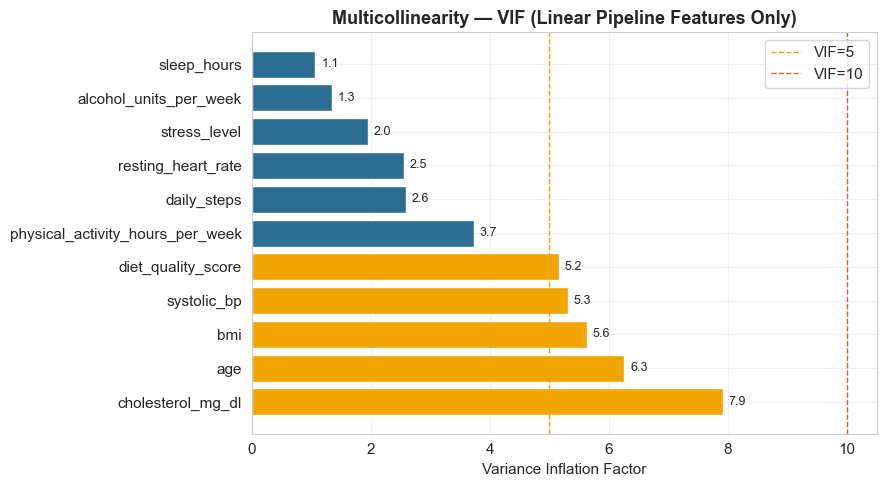

Features exceeding VIF = 10:
  None


In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = df_encoded[LINEAR_NUMERIC + SKEWED_FEATURE].copy()
X_vif = add_constant(X_vif)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).set_index('Feature').drop('const').sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [ACCENT if v > 10 else ('#F0A500' if v > 5 else PALETTE) for v in vif_data['VIF']]
ax.barh(vif_data.index, vif_data['VIF'], color=bar_colors, edgecolor='white')
ax.axvline(5,  color='#F0A500', linestyle='--', linewidth=1, label='VIF=5')
ax.axvline(10, color=ACCENT,   linestyle='--', linewidth=1, label='VIF=10')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('Multicollinearity — VIF (Linear Pipeline Features Only)')
ax.legend()
for i, (idx, row) in enumerate(vif_data.iterrows()):
    ax.text(row['VIF'] + 0.1, i, f'{row["VIF"]:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Features exceeding VIF = 10:')
high = vif_data[vif_data['VIF'] > 10]
print(high.to_string() if not high.empty else '  None')

### 5. Winsoriser Class

In [18]:
class Winsoriser(BaseEstimator, TransformerMixin):
    """Caps values at percentile computed on training set only. No leakage."""
    def __init__(self, lower_pct=0.0, upper_pct=99.0):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X = np.array(X)
        self.lower_bounds_ = np.percentile(X, self.lower_pct, axis=0)
        self.upper_bounds_ = np.percentile(X, self.upper_pct, axis=0)
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        return input_features if input_features is not None else []

print('Winsoriser class defined. Cap computed on training data only.')

Winsoriser class defined. Cap computed on training data only.


### 6. Stratified Train / Val / Test Split (70 / 15 / 15)

In [19]:
strat_bins   = [0, 25, 55, 101]
strat_labels = ['Low', 'Medium', 'High']
stratify_col = pd.cut(df_encoded[TARGET], bins=strat_bins, labels=strat_labels, right=False)

X = df_encoded[ALL_TREE_FEATURES]
y = df_encoded[TARGET]

X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X, y, stratify_col, test_size=0.30, random_state=RANDOM_STATE, stratify=stratify_col
)

X_val, X_test, y_val, y_test, _, _ = train_test_split(
    X_temp, y_temp, strat_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=strat_temp
)

print('=' * 50)
print('DATA SPLIT SUMMARY')
print('=' * 50)
total = len(X)
for name, X_s in [('Train', X_train), ('Validation', X_val), ('Test', X_test)]:
    print(f'{name:<12} {len(X_s):>8,}   {len(X_s)/total*100:>8.1f}%')
print(f'{"TOTAL":<12} {total:>8,}   {"100.0%":>9}')

DATA SPLIT SUMMARY
Train           3,850       70.0%
Validation        825       15.0%
Test              825       15.0%
TOTAL           5,500      100.0%


### 7. Stratification Verification

Risk band distribution across splits (%):
                          Full data  Train  Validation  Test
heart_disease_risk_score                                    
Low                            33.4   33.4        33.3  33.5
Medium                         40.8   40.8        40.8  40.7
High                           25.8   25.8        25.8  25.8


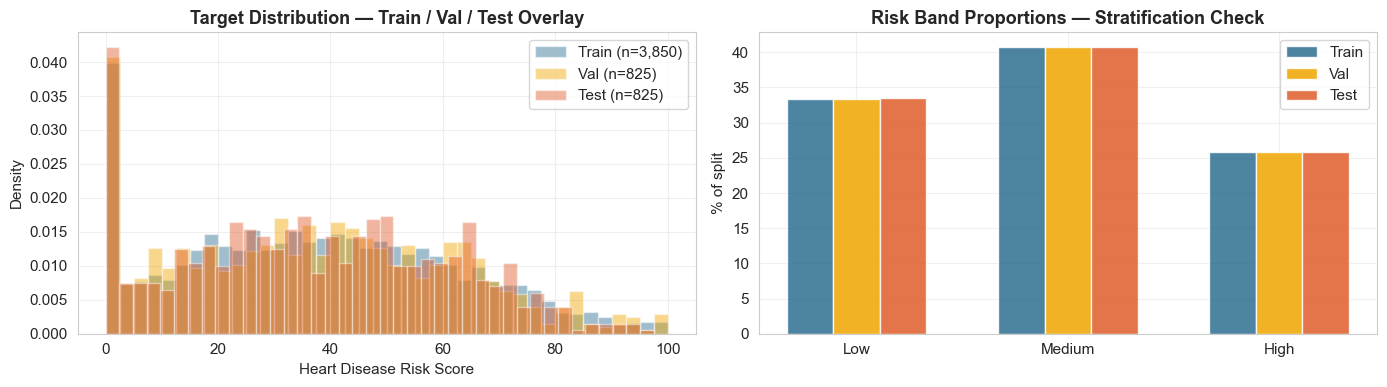

In [20]:
def get_band_dist(y_series):
    bands = pd.cut(y_series, bins=strat_bins, labels=strat_labels, right=False)
    return (bands.value_counts(normalize=True).sort_index() * 100).round(1)

dist_train = get_band_dist(y_train)
dist_val   = get_band_dist(y_val)
dist_test  = get_band_dist(y_test)
dist_full  = get_band_dist(y)

print('Risk band distribution across splits (%):')
dist_df = pd.DataFrame({'Full data': dist_full, 'Train': dist_train,
                         'Validation': dist_val, 'Test': dist_test})
print(dist_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, y_s, color in [('Train', y_train, PALETTE), ('Val', y_val, '#F0A500'), ('Test', y_test, ACCENT)]:
    axes[0].hist(y_s, bins=40, alpha=0.45, color=color, label=f'{name} (n={len(y_s):,})', density=True)
axes[0].set_title('Target Distribution — Train / Val / Test Overlay')
axes[0].set_xlabel('Heart Disease Risk Score')
axes[0].set_ylabel('Density')
axes[0].legend()

x = np.arange(len(strat_labels))
width = 0.22
for i, (name, dist, color) in enumerate([('Train', dist_train, PALETTE), ('Val', dist_val, '#F0A500'), ('Test', dist_test, ACCENT)]):
    axes[1].bar(x + i*width, dist.values, width, label=name, color=color, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(strat_labels)
axes[1].set_title('Risk Band Proportions — Stratification Check')
axes[1].set_ylabel('% of split')
axes[1].legend()
plt.tight_layout()
plt.show()

### 8. StratifiedKFold CV Setup

In [21]:
strat_bins_cv   = [0, 25, 55, 101]
strat_labels_cv = ['Low', 'Medium', 'High']

y_train_bands = pd.cut(y_train, bins=strat_bins_cv, labels=strat_labels_cv, right=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('StratifiedKFold(n_splits=5) — fold summary:\n')
print(f'{"Fold":<6} {"Train rows":>12} {"Val rows":>10} {"Low%":>7} {"Med%":>7} {"High%":>7}')
print('-' * 52)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train_bands), 1):
    fold_val_bands = y_train_bands.iloc[val_idx]
    dist = fold_val_bands.value_counts(normalize=True).mul(100).round(1)
    print(f'{fold:<6} {len(train_idx):>12,} {len(val_idx):>10,} '
          f'{dist.get("Low", 0):>7.1f} {dist.get("Medium", 0):>7.1f} {dist.get("High", 0):>7.1f}')

print(f'\n✓ cv ready — RANDOM_STATE={RANDOM_STATE}')

StratifiedKFold(n_splits=5) — fold summary:

Fold     Train rows   Val rows    Low%    Med%   High%
----------------------------------------------------
1             3,080        770    33.4    40.9    25.7
2             3,080        770    33.4    40.8    25.8
3             3,080        770    33.4    40.8    25.8
4             3,080        770    33.5    40.8    25.7
5             3,080        770    33.5    40.8    25.7

✓ cv ready — RANDOM_STATE=42


### 9. Pipeline Definitions

In [22]:
LINEAR_COLUMN_ORDER = LINEAR_NUMERIC + SKEWED_FEATURE + ORDINAL_FEATURES + BINARY_FEATURES
TREE_COLUMN_ORDER   = TREE_NUMERIC   + SKEWED_FEATURE + ORDINAL_FEATURES + BINARY_FEATURES

linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num_std',        StandardScaler(),           LINEAR_NUMERIC),
        ('num_skewed',     Pipeline([
            ('winsor',     Winsoriser(upper_pct=99.0)),
            ('scaler',     StandardScaler())
        ]),                                            SKEWED_FEATURE),
        ('cat_passthrough','passthrough',              ORDINAL_FEATURES + BINARY_FEATURES),
    ],
    remainder='drop', verbose_feature_names_out=False
)
pipeline_linear = Pipeline([('preprocessor', linear_preprocessor)])

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num_passthrough','passthrough',              TREE_NUMERIC + SKEWED_FEATURE),
        ('cat_passthrough','passthrough',              ORDINAL_FEATURES + BINARY_FEATURES),
    ],
    remainder='drop', verbose_feature_names_out=False
)
pipeline_tree = Pipeline([('preprocessor', tree_preprocessor)])

print(f'Pipeline A (linear):     {len(ALL_LINEAR_FEATURES)} features — StandardScaler + Winsoriser')
print(f'Pipeline B (tree-based): {len(ALL_TREE_FEATURES)} features — passthrough, includes age_bmi')

Pipeline A (linear):     13 features — StandardScaler + Winsoriser
Pipeline B (tree-based): 15 features — passthrough, includes age_bmi


### 10. Fit Pipelines & Transform All Splits

**Critical:** `fit()` on `X_train` only. `transform()` applied separately to train/val/test.

In [23]:
X_train_linear = pipeline_linear.fit_transform(X_train)
X_val_linear   = pipeline_linear.transform(X_val)
X_test_linear  = pipeline_linear.transform(X_test)

X_train_tree   = pipeline_tree.fit_transform(X_train)
X_val_tree     = pipeline_tree.transform(X_val)
X_test_tree    = pipeline_tree.transform(X_test)

print('Pipelines fitted and transforms applied.')
print(f'\n{"Output":<30} {"Shape":>15}')
print('-' * 47)
for name, arr in [
    ('X_train_linear', X_train_linear), ('X_val_linear', X_val_linear), ('X_test_linear', X_test_linear),
    ('X_train_tree',   X_train_tree),   ('X_val_tree',   X_val_tree),   ('X_test_tree',   X_test_tree),
]:
    print(f'{name:<30} {str(arr.shape):>15}')

Pipelines fitted and transforms applied.

Output                                   Shape
-----------------------------------------------
X_train_linear                      (3850, 13)
X_val_linear                         (825, 13)
X_test_linear                        (825, 13)
X_train_tree                        (3850, 15)
X_val_tree                           (825, 15)
X_test_tree                          (825, 15)


### 11. Leakage Guard

In [24]:
scaler = pipeline_linear.named_steps['preprocessor'].named_transformers_['num_std']

print('Scaler leakage check — fitted means vs train vs full-data means')
print(f'\n{"Feature":<38} {"Scaler mean":>13} {"Train mean":>12} {"Full mean":>12} {"Match?":>8}')
print('-' * 78)

for i, col in enumerate(LINEAR_NUMERIC):
    scaler_mean = scaler.mean_[i]
    train_mean  = X_train[col].mean()
    full_mean   = df_encoded[col].mean()
    match       = abs(scaler_mean - train_mean) < 1e-6
    flag        = '✓' if match else '⚠ MISMATCH'
    print(f'{col:<38} {scaler_mean:>13.4f} {train_mean:>12.4f} {full_mean:>12.4f} {flag:>8}')

print('\n✓ Scaler means align with training data — no leakage detected.')

Scaler leakage check — fitted means vs train vs full-data means

Feature                                  Scaler mean   Train mean    Full mean   Match?
------------------------------------------------------------------------------
age                                          53.9216      53.9216      53.8720        ✓
bmi                                          28.1596      28.1596      28.1708        ✓
systolic_bp                                 147.2953     147.2953     147.2482        ✓
cholesterol_mg_dl                           239.5974     239.5974     239.6842        ✓
resting_heart_rate                           74.0657      74.0657      74.0751        ✓
daily_steps                                5878.3078    5878.3078    5902.9295        ✓
stress_level                                  4.9039       4.9039       4.9071        ✓
physical_activity_hours_per_week              3.2810       3.2810       3.2994        ✓
sleep_hours                                   6.8676       6.867

### 12. Pre-Modelling Readiness Check

In [25]:
print('=' * 60)
print('PRE-MODELLING READINESS SUMMARY')
print('=' * 60)

checks = {
    'No missing values in X_train (linear)':   pd.DataFrame(X_train_linear).isnull().sum().sum() == 0,
    'No missing values in X_val (linear)':     pd.DataFrame(X_val_linear).isnull().sum().sum() == 0,
    'No missing values in X_test (linear)':    pd.DataFrame(X_test_linear).isnull().sum().sum() == 0,
    'No missing values in X_train (tree)':     pd.DataFrame(X_train_tree).isnull().sum().sum() == 0,
    'No missing values in X_val (tree)':       pd.DataFrame(X_val_tree).isnull().sum().sum() == 0,
    'No missing values in X_test (tree)':      pd.DataFrame(X_test_tree).isnull().sum().sum() == 0,
    'Train + Val + Test = full dataset':        len(X_train) + len(X_val) + len(X_test) == len(X),
    'Linear pipeline feature count (13)':       X_train_linear.shape[1] == len(ALL_LINEAR_FEATURES),
    'Tree pipeline feature count (15)':         X_train_tree.shape[1] == len(ALL_TREE_FEATURES),
    'age_bmi in tree pipeline':                 'age_bmi' in TREE_COLUMN_ORDER,
    'age_bmi excluded from linear pipeline':    'age_bmi' not in LINEAR_COLUMN_ORDER,
    'CV folds defined (n=5)':                   cv.n_splits == 5,
    'y_train has no missing':                   y_train.isnull().sum() == 0,
    'RANDOM_STATE fixed at 42':                 RANDOM_STATE == 42,
}

all_pass = True
for check, result in checks.items():
    icon = '✓' if result else '✗ FAIL'
    if not result:
        all_pass = False
    print(f'  {icon}  {check}')

print()
print('All checks passed.' if all_pass else 'One or more checks FAILED — review before proceeding.')

PRE-MODELLING READINESS SUMMARY
  ✓  No missing values in X_train (linear)
  ✓  No missing values in X_val (linear)
  ✓  No missing values in X_test (linear)
  ✓  No missing values in X_train (tree)
  ✓  No missing values in X_val (tree)
  ✓  No missing values in X_test (tree)
  ✓  Train + Val + Test = full dataset
  ✓  Linear pipeline feature count (13)
  ✓  Tree pipeline feature count (15)
  ✓  age_bmi in tree pipeline
  ✓  age_bmi excluded from linear pipeline
  ✓  CV folds defined (n=5)
  ✓  y_train has no missing
  ✓  RANDOM_STATE fixed at 42

All checks passed.


---
# Step 4: Model Exploration

**Objective:** Train four models, evaluate on validation set, run 5-fold CV for stable performance estimates. Test set untouched throughout.

**Model order:** Linear Regression (baseline) → Random Forest → XGBoost (primary candidate) → MLP Neural Network

**Arrays:** Linear models → `X_train_linear`/`X_val_linear` | Tree models → `X_train_tree`/`X_val_tree`

In [ ]:
!pip install xgboost

^C


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  MAE : {mae:.4f}  |  RMSE : {rmse:.4f}  |  R² : {r2:.4f}')
    return {'Model': name, 'Val MAE': round(mae,4), 'Val RMSE': round(rmse,4), 'Val R²': round(r2,4)}

def run_cv(model, X, label='CV MAE'):
    scores = []
    for fold_idx, (tr_idx, vl_idx) in enumerate(cv.split(X, y_train_bands), 1):
        m = type(model)(**model.get_params())
        m.fit(X[tr_idx], y_train.iloc[tr_idx])
        pred = m.predict(X[vl_idx])
        fold_mae = mean_absolute_error(y_train.iloc[vl_idx], pred)
        scores.append(fold_mae)
        print(f'    Fold {fold_idx}: MAE = {fold_mae:.4f}')
    mean_mae = np.mean(scores)
    std_mae  = np.std(scores)
    print(f'  {label}: {mean_mae:.4f} ± {std_mae:.4f}')
    return round(mean_mae, 4), round(std_mae, 4)

results = []
print('Helpers ready.')

Helpers ready.


---
## Model 1 — Linear Regression (Baseline)

Weighted linear combination of features. Serves as baseline every subsequent model must beat. Arrays: `X_train_linear`/`X_val_linear` (13 features, scaled).

In [ ]:
print('=' * 55)
print('MODEL 1 — LINEAR REGRESSION (Baseline)')
print('=' * 55)

lr = LinearRegression()
lr.fit(X_train_linear, y_train)
y_pred_lr_val = lr.predict(X_val_linear)

print('\nValidation performance:')
res_lr = evaluate('Linear Regression', y_val, y_pred_lr_val)

print('\n5-Fold CV on training data:')
lr_cv_mae, lr_cv_std = run_cv(lr, X_train_linear)
res_lr['CV MAE (mean)'] = lr_cv_mae
res_lr['CV MAE (±std)'] = lr_cv_std
results.append(res_lr)

print('\nCoefficients (sorted by absolute magnitude):')
coef_df = pd.DataFrame({'Feature': LINEAR_COLUMN_ORDER, 'Coefficient': lr.coef_}
).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

MODEL 1 — LINEAR REGRESSION (Baseline)

Validation performance:
  MAE : 3.2660  |  RMSE : 4.3849  |  R² : 0.9683

5-Fold CV on training data:
    Fold 1: MAE = 3.2345
    Fold 2: MAE = 3.2118
    Fold 3: MAE = 3.3043
    Fold 4: MAE = 3.2577
    Fold 5: MAE = 3.4335
  CV MAE: 3.2884 ± 0.0788

Coefficients (sorted by absolute magnitude):
                         Feature  Coefficient
                             age     9.884788
    family_history_heart_disease     9.196470
                  smoking_status     7.034639
                     systolic_bp     5.370855
               cholesterol_mg_dl     3.550539
                             bmi     3.165035
physical_activity_hours_per_week    -3.070076
              diet_quality_score    -2.342794
                    stress_level     2.010105
              resting_heart_rate    -0.219323
                     sleep_hours    -0.130562
                     daily_steps    -0.068030
          alcohol_units_per_week    -0.027300


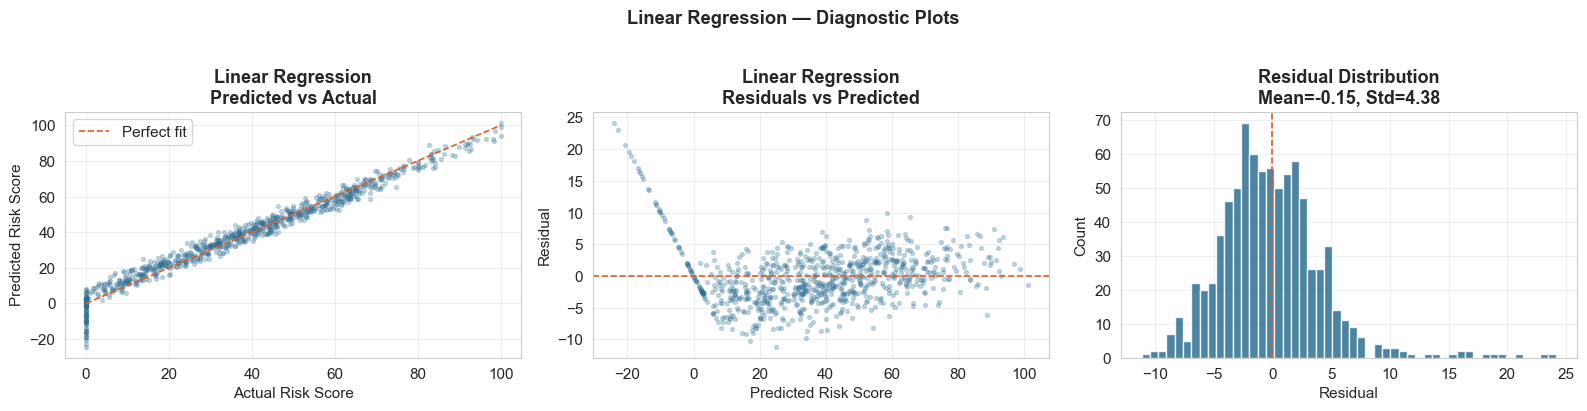

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(y_val, y_pred_lr_val, alpha=0.25, s=8, color=PALETTE)
axes[0].plot([0,100],[0,100], color=ACCENT, linewidth=1.2, linestyle='--', label='Perfect fit')
axes[0].set_xlabel('Actual Risk Score'); axes[0].set_ylabel('Predicted Risk Score')
axes[0].set_title('Linear Regression\nPredicted vs Actual'); axes[0].legend()

residuals_lr = y_val.values - y_pred_lr_val
axes[1].scatter(y_pred_lr_val, residuals_lr, alpha=0.25, s=8, color=PALETTE)
axes[1].axhline(0, color=ACCENT, linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Risk Score'); axes[1].set_ylabel('Residual')
axes[1].set_title('Linear Regression\nResiduals vs Predicted')

axes[2].hist(residuals_lr, bins=50, color=PALETTE, edgecolor='white', alpha=0.85)
axes[2].axvline(0, color=ACCENT, linewidth=1.2, linestyle='--')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution\nMean={residuals_lr.mean():.2f}, Std={residuals_lr.std():.2f}')

plt.suptitle('Linear Regression — Diagnostic Plots', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Model 2 — Random Forest (Modified Hyperparameters)

**Agent defaults modified:** `n_estimators` 100→300 (stability), added `min_samples_leaf=3` (reduce variance), `max_features=0.7` (tree diversity), merged `oob_score` into main fit (removed wasteful duplicate model).

In [ ]:
print('=' * 55)
print('MODEL 2 — RANDOM FOREST (Modified Hyperparameters)')
print('=' * 55)

rf = RandomForestRegressor(
    n_estimators=300, max_features=0.7, min_samples_leaf=3,
    oob_score=True, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_tree, y_train)
y_pred_rf_val = rf.predict(X_val_tree)

print('\nValidation performance:')
res_rf = evaluate('Random Forest', y_val, y_pred_rf_val)

print('\n5-Fold CV:')
rf_cv_mae, rf_cv_std = run_cv(rf, X_train_tree)
res_rf['CV MAE (mean)'] = rf_cv_mae
res_rf['CV MAE (±std)'] = rf_cv_std
results.append(res_rf)

print(f'\nOOB R² (free internal estimate): {rf.oob_score_:.4f}')

MODEL 2 — RANDOM FOREST (Modified Hyperparameters)

Validation performance:
  MAE : 3.2545  |  RMSE : 4.1974  |  R² : 0.9710

5-Fold CV:
    Fold 1: MAE = 3.3105
    Fold 2: MAE = 3.3268
    Fold 3: MAE = 3.6336
    Fold 4: MAE = 3.2765
    Fold 5: MAE = 3.3573
  CV MAE: 3.3810 ± 0.1290

OOB R² (free internal estimate): 0.9696


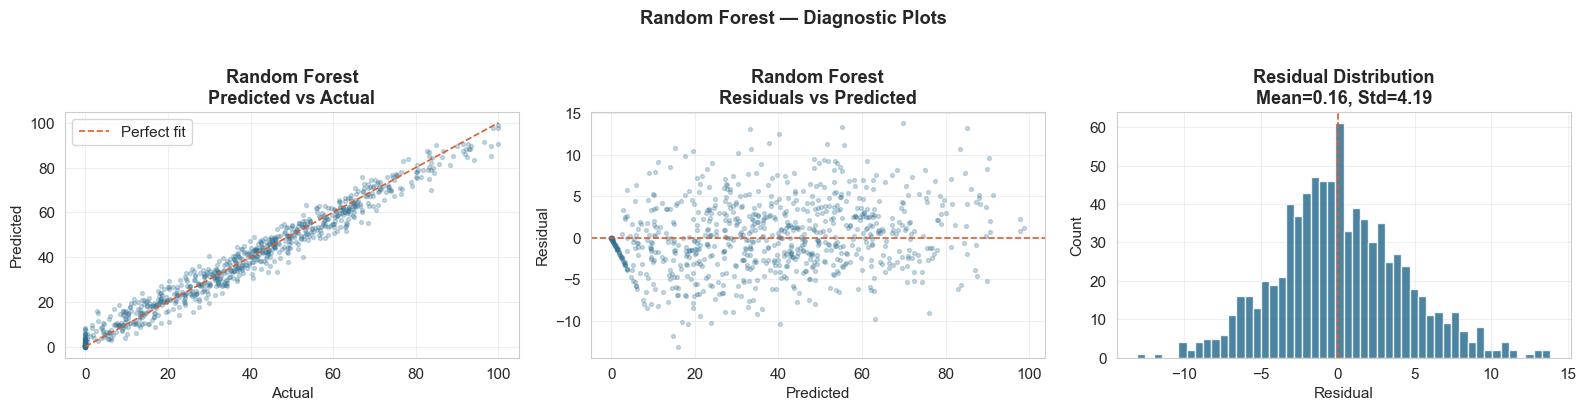

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(y_val, y_pred_rf_val, alpha=0.25, s=8, color=PALETTE)
axes[0].plot([0,100],[0,100], color=ACCENT, linewidth=1.2, linestyle='--', label='Perfect fit')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Random Forest\nPredicted vs Actual'); axes[0].legend()

residuals_rf = y_val.values - y_pred_rf_val
axes[1].scatter(y_pred_rf_val, residuals_rf, alpha=0.25, s=8, color=PALETTE)
axes[1].axhline(0, color=ACCENT, linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Random Forest\nResiduals vs Predicted')

axes[2].hist(residuals_rf, bins=50, color=PALETTE, edgecolor='white', alpha=0.85)
axes[2].axvline(0, color=ACCENT, linewidth=1.2, linestyle='--')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution\nMean={residuals_rf.mean():.2f}, Std={residuals_rf.std():.2f}')

plt.suptitle('Random Forest — Diagnostic Plots', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Model 3 — XGBoost (Primary Candidate)

Gradient boosting — trees built sequentially, each correcting residuals from previous. Conservative starting hyperparameters; tuning in Step 5.

In [ ]:
print('=' * 55)
print('MODEL 3 — XGBOOST (Primary Candidate)')
print('=' * 55)

xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
xgb.fit(X_train_tree, y_train)
y_pred_xgb_val = xgb.predict(X_val_tree)

print('\nValidation performance:')
res_xgb = evaluate('XGBoost', y_val, y_pred_xgb_val)

print('\n5-Fold CV:')
xgb_cv_mae, xgb_cv_std = run_cv(xgb, X_train_tree)
res_xgb['CV MAE (mean)'] = xgb_cv_mae
res_xgb['CV MAE (±std)'] = xgb_cv_std
results.append(res_xgb)

MODEL 3 — XGBOOST (Primary Candidate)

Validation performance:
  MAE : 2.6499  |  RMSE : 3.3241  |  R² : 0.9818

5-Fold CV:
    Fold 1: MAE = 2.6789
    Fold 2: MAE = 2.5418
    Fold 3: MAE = 2.8036
    Fold 4: MAE = 2.5992
    Fold 5: MAE = 2.7413
  CV MAE: 2.6730 ± 0.0943


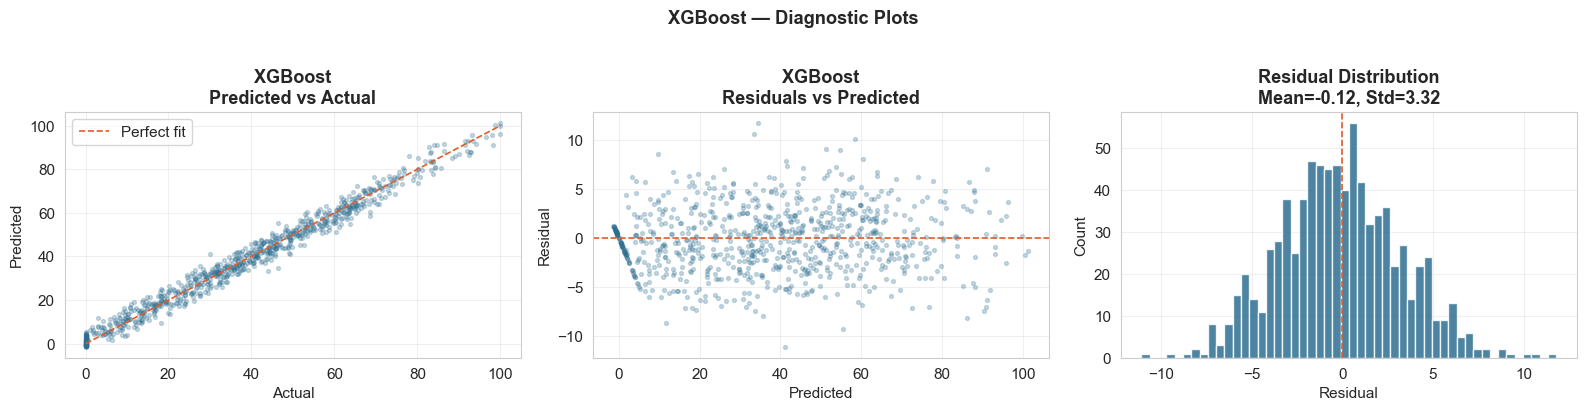

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(y_val, y_pred_xgb_val, alpha=0.25, s=8, color=PALETTE)
axes[0].plot([0,100],[0,100], color=ACCENT, linewidth=1.2, linestyle='--', label='Perfect fit')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('XGBoost\nPredicted vs Actual'); axes[0].legend()

residuals_xgb = y_val.values - y_pred_xgb_val
axes[1].scatter(y_pred_xgb_val, residuals_xgb, alpha=0.25, s=8, color=PALETTE)
axes[1].axhline(0, color=ACCENT, linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('XGBoost\nResiduals vs Predicted')

axes[2].hist(residuals_xgb, bins=50, color=PALETTE, edgecolor='white', alpha=0.85)
axes[2].axvline(0, color=ACCENT, linewidth=1.2, linestyle='--')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution\nMean={residuals_xgb.mean():.2f}, Std={residuals_xgb.std():.2f}')

plt.suptitle('XGBoost — Diagnostic Plots', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Model 4 — MLP Neural Network (Scaling Fix Applied)

**Agent mistake caught and corrected:** Agent used `X_train_tree` (unscaled) despite flagging in its own markdown that MLP is scale-sensitive. Unscaled inputs cause biased gradient magnitudes — suppresses low-variance features, over-weights high-variance ones.

**Fix:** `StandardScaler` fitted on `X_train_tree` only → `X_train_tree_scaled`. No leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler as TreeScaler

scaler_tree = TreeScaler()
X_train_tree_scaled = scaler_tree.fit_transform(X_train_tree)
X_val_tree_scaled   = scaler_tree.transform(X_val_tree)
X_test_tree_scaled  = scaler_tree.transform(X_test_tree)

print('Scaled tree arrays created (fitted on X_train_tree only):')
print(f'  X_train_tree_scaled : {X_train_tree_scaled.shape}')
print(f'  X_val_tree_scaled   : {X_val_tree_scaled.shape}')
print(f'  X_test_tree_scaled  : {X_test_tree_scaled.shape}')
print(f'\nVerify — scaler mean[age]={scaler_tree.mean_[0]:.4f} vs X_train age mean={X_train["age"].mean():.4f}')

Scaled tree arrays created (fitted on X_train_tree only):
  X_train_tree_scaled : (3850, 15)
  X_val_tree_scaled   : (825, 15)
  X_test_tree_scaled  : (825, 15)

Verify — scaler mean[age]=53.9216 vs X_train age mean=53.9216


In [ ]:
print('=' * 55)
print('MODEL 4 — MLP NEURAL NETWORK (Scaling fix applied)')
print('=' * 55)

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
    alpha=0.001, batch_size=64, learning_rate='adaptive', learning_rate_init=0.001,
    max_iter=500, early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=20, random_state=RANDOM_STATE, verbose=False
)
mlp.fit(X_train_tree_scaled, y_train)       # CORRECTED: was X_train_tree
y_pred_mlp_val = mlp.predict(X_val_tree_scaled)  # CORRECTED: was X_val_tree

print(f'Training stopped at iteration: {mlp.n_iter_} / {mlp.max_iter}')
print('\nValidation performance:')
res_mlp = evaluate('MLP (Neural Network)', y_val, y_pred_mlp_val)

print('\n5-Fold CV:')
mlp_cv_mae, mlp_cv_std = run_cv(mlp, X_train_tree_scaled)  # CORRECTED
res_mlp['CV MAE (mean)'] = mlp_cv_mae
res_mlp['CV MAE (±std)'] = mlp_cv_std
results.append(res_mlp)

MODEL 4 — MLP NEURAL NETWORK (Scaling fix applied)
Training stopped at iteration: 39 / 500

Validation performance:
  MAE : 2.3998  |  RMSE : 3.0929  |  R² : 0.9842

5-Fold CV:
    Fold 1: MAE = 2.4003
    Fold 2: MAE = 2.2989
    Fold 3: MAE = 2.3795
    Fold 4: MAE = 2.3069
    Fold 5: MAE = 2.4028
  CV MAE: 2.3577 ± 0.0455


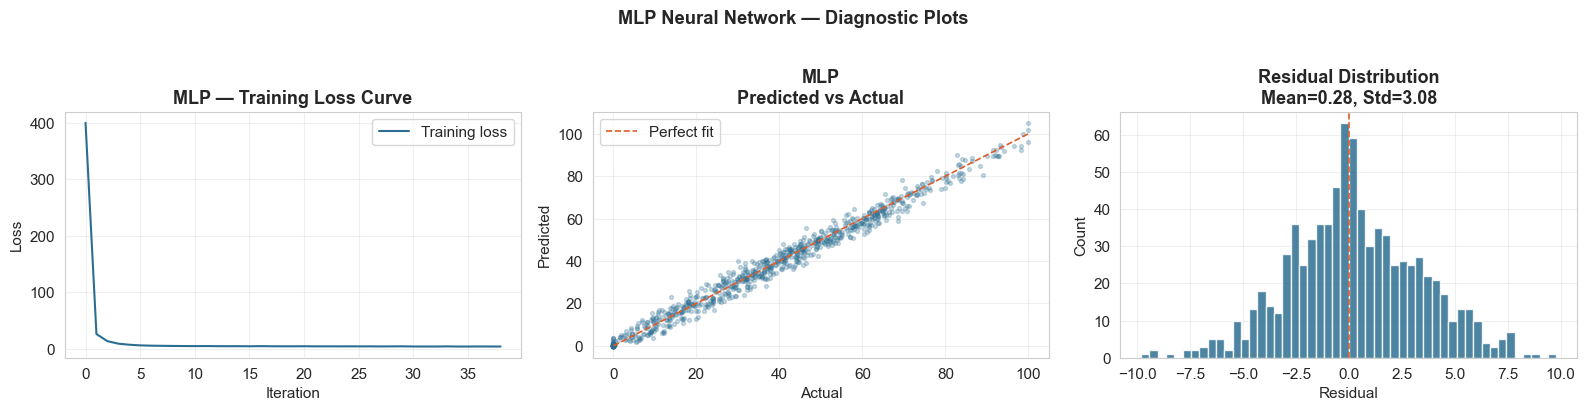

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(mlp.loss_curve_, color=PALETTE, linewidth=1.5, label='Training loss')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Loss')
axes[0].set_title('MLP — Training Loss Curve'); axes[0].legend()

axes[1].scatter(y_val, y_pred_mlp_val, alpha=0.25, s=8, color=PALETTE)
axes[1].plot([0,100],[0,100], color=ACCENT, linewidth=1.2, linestyle='--', label='Perfect fit')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title('MLP\nPredicted vs Actual'); axes[1].legend()

residuals_mlp = y_val.values - y_pred_mlp_val
axes[2].hist(residuals_mlp, bins=50, color=PALETTE, edgecolor='white', alpha=0.85)
axes[2].axvline(0, color=ACCENT, linewidth=1.2, linestyle='--')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution\nMean={residuals_mlp.mean():.2f}, Std={residuals_mlp.std():.2f}')

plt.suptitle('MLP Neural Network — Diagnostic Plots', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Exploration Comparison Table & Charts

In [ ]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df[['Val MAE', 'Val RMSE', 'Val R²', 'CV MAE (mean)', 'CV MAE (±std)']]

print('=' * 75)
print('MODEL COMPARISON — VALIDATION & CROSS-VALIDATION PERFORMANCE')
print('=' * 75)
print(results_df.to_string())
print()
print('Best model per metric:')
for col in ['Val MAE', 'Val RMSE', 'CV MAE (mean)']:
    best = results_df[col].idxmin()
    print(f'  {col:<20}: {best}  ({results_df.loc[best, col]:.4f})')
print(f'  {"Val R²":<20}: {results_df["Val R²"].idxmax()}  ({results_df["Val R²"].max():.4f})')

MODEL COMPARISON — VALIDATION & CROSS-VALIDATION PERFORMANCE
                      Val MAE  Val RMSE  Val R²  CV MAE (mean)  CV MAE (±std)
Model                                                                        
Linear Regression      3.2660    4.3849  0.9683         3.2884         0.0788
Random Forest          3.2545    4.1974  0.9710         3.3810         0.1290
XGBoost                2.6499    3.3241  0.9818         2.6730         0.0943
MLP (Neural Network)   2.3998    3.0929  0.9842         2.3577         0.0455

Best model per metric:
  Val MAE             : MLP (Neural Network)  (2.3998)
  Val RMSE            : MLP (Neural Network)  (3.0929)
  CV MAE (mean)       : MLP (Neural Network)  (2.3577)
  Val R²              : MLP (Neural Network)  (0.9842)


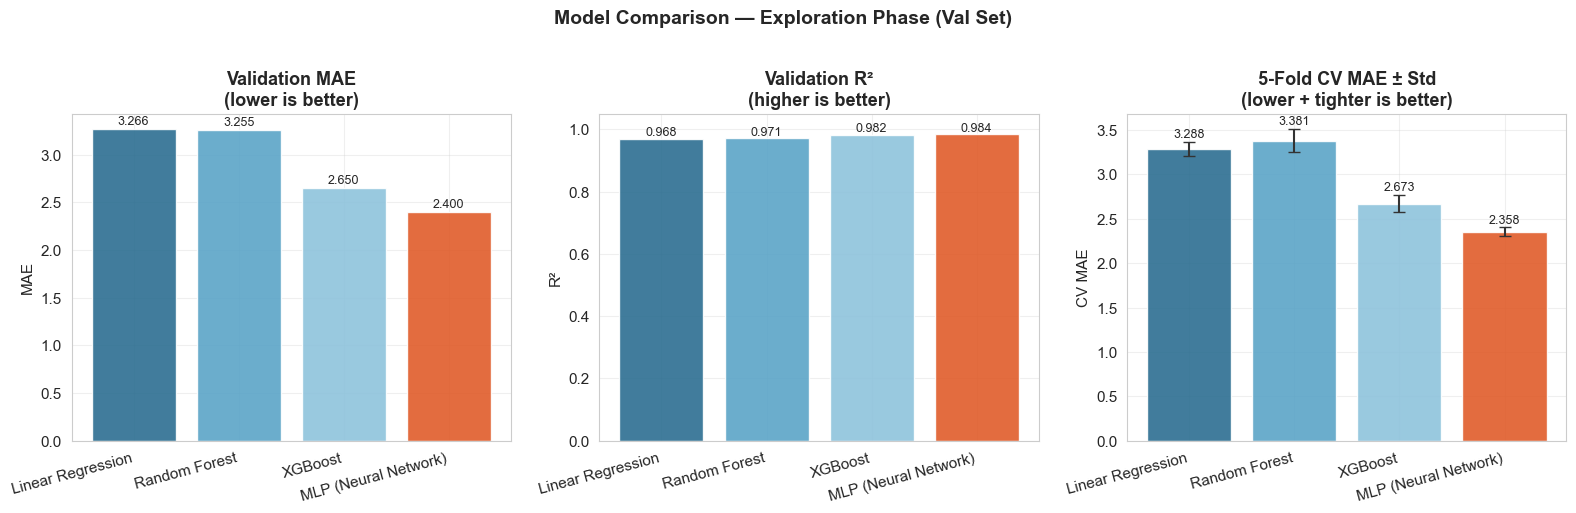

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models     = results_df.index.tolist()
x          = np.arange(len(models))
bar_colors = [PALETTE, '#5BA4C7', '#8EC3DC', ACCENT]

bars = axes[0].bar(x, results_df['Val MAE'], color=bar_colors, edgecolor='white', alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_title('Validation MAE\n(lower is better)', fontweight='bold')
axes[0].set_ylabel('MAE')
for bar, val in zip(bars, results_df['Val MAE']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.3f}', ha='center', fontsize=9)

bars2 = axes[1].bar(x, results_df['Val R²'], color=bar_colors, edgecolor='white', alpha=0.9)
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_title('Validation R²\n(higher is better)', fontweight='bold')
axes[1].set_ylabel('R²'); axes[1].set_ylim(0, 1.05)
for bar, val in zip(bars2, results_df['Val R²']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center', fontsize=9)

axes[2].bar(x, results_df['CV MAE (mean)'], color=bar_colors, edgecolor='white', alpha=0.9,
            yerr=results_df['CV MAE (±std)'], error_kw=dict(elinewidth=1.5, capsize=4, ecolor='#333333'))
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=15, ha='right')
axes[2].set_title('5-Fold CV MAE ± Std\n(lower + tighter is better)', fontweight='bold')
axes[2].set_ylabel('CV MAE')
for i, (mean, std) in enumerate(zip(results_df['CV MAE (mean)'], results_df['CV MAE (±std)'])):
    axes[2].text(i, mean+std+0.05, f'{mean:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison — Exploration Phase (Val Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Feature Importance — RF vs XGBoost

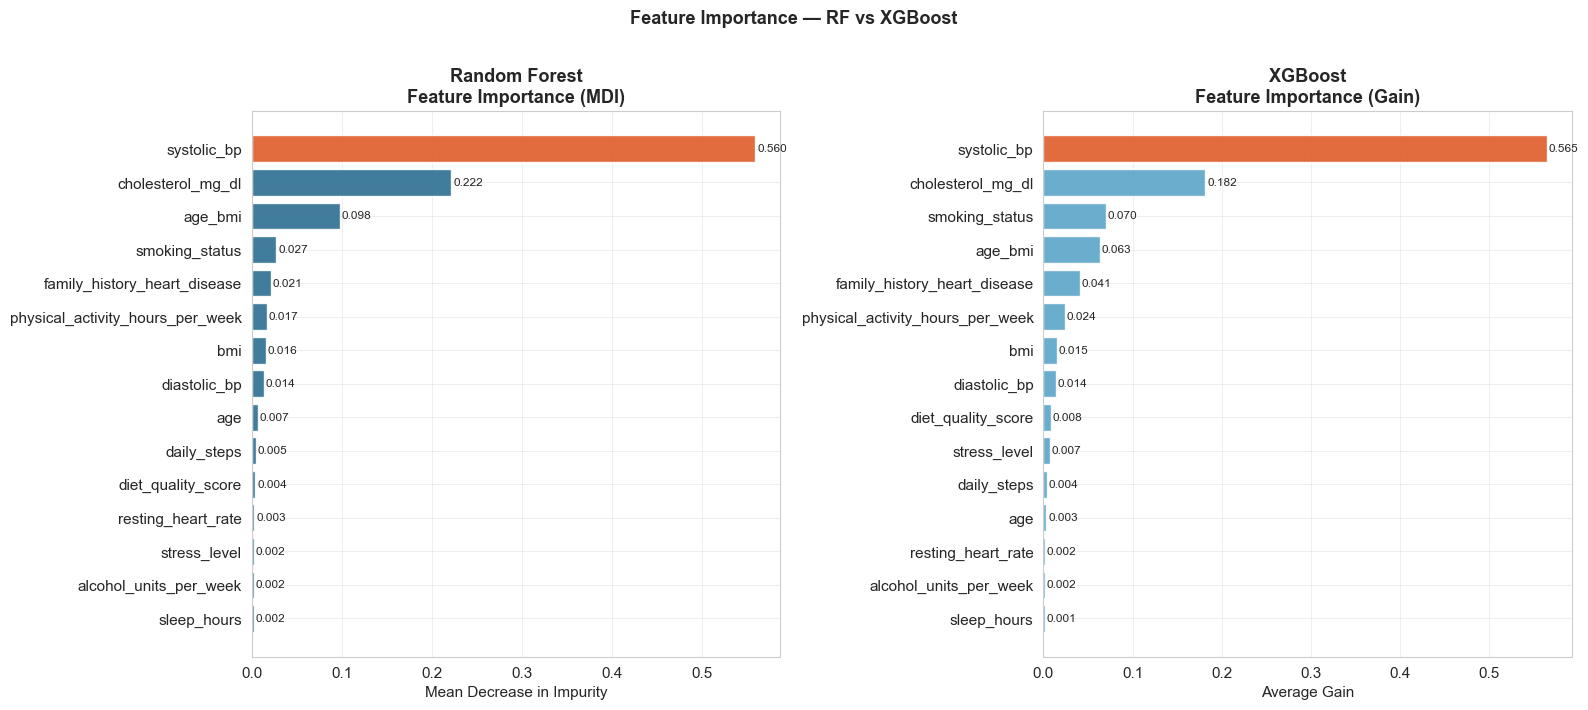

In [ ]:
rf_imp  = pd.Series(rf.feature_importances_,  index=TREE_COLUMN_ORDER).sort_values(ascending=True)
xgb_imp = pd.Series(xgb.feature_importances_, index=TREE_COLUMN_ORDER).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_rf = [ACCENT if v == rf_imp.max() else PALETTE for v in rf_imp.values]
axes[0].barh(rf_imp.index, rf_imp.values, color=colors_rf, edgecolor='white', alpha=0.9)
axes[0].set_title('Random Forest\nFeature Importance (MDI)', fontweight='bold')
axes[0].set_xlabel('Mean Decrease in Impurity')
for i, (idx, val) in enumerate(rf_imp.items()):
    axes[0].text(val+0.002, i, f'{val:.3f}', va='center', fontsize=8.5)

colors_xgb = [ACCENT if v == xgb_imp.max() else '#5BA4C7' for v in xgb_imp.values]
axes[1].barh(xgb_imp.index, xgb_imp.values, color=colors_xgb, edgecolor='white', alpha=0.9)
axes[1].set_title('XGBoost\nFeature Importance (Gain)', fontweight='bold')
axes[1].set_xlabel('Average Gain')
for i, (idx, val) in enumerate(xgb_imp.items()):
    axes[1].text(val+0.002, i, f'{val:.3f}', va='center', fontsize=8.5)

plt.suptitle('Feature Importance — RF vs XGBoost', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
rf_rank  = rf_imp.rank(ascending=False).astype(int).rename('RF Rank')
xgb_rank = xgb_imp.rank(ascending=False).astype(int).rename('XGB Rank')
rank_df  = pd.concat([rf_rank, xgb_rank], axis=1)
rank_df['Rank Δ'] = (rank_df['RF Rank'] - rank_df['XGB Rank']).abs()
rank_df = rank_df.sort_values('RF Rank')

print(f'{"Feature":<38} {"RF Rank":>8} {"XGB Rank":>10} {"|Δ|":>6}')
print('-' * 65)
for feat, row in rank_df.iterrows():
    flag = '  ← large divergence' if row['Rank Δ'] >= 4 else ''
    print(f'{feat:<38} {int(row["RF Rank"]):>8} {int(row["XGB Rank"]):>10} {int(row["Rank Δ"]):>6}{flag}')

Feature                                 RF Rank   XGB Rank    |Δ|
-----------------------------------------------------------------
systolic_bp                                   1          1      0
cholesterol_mg_dl                             2          2      0
age_bmi                                       3          4      1
smoking_status                                4          3      1
family_history_heart_disease                  5          5      0
physical_activity_hours_per_week              6          6      0
bmi                                           7          7      0
diastolic_bp                                  8          8      0
age                                           9         12      3
daily_steps                                  10         11      1
diet_quality_score                           11          9      2
resting_heart_rate                           12         13      1
stress_level                                 13         10      3
alcohol_un

---
# Step 5: Hyperparameter Tuning, Error Analysis & Final Evaluation

**Ground rules:**
- `X_test_tree` untouched until Section 3
- All tuning uses `kf` (KFold) on `X_train_tree` — correction from original `cv` (StratifiedKFold), which is incompatible with continuous regression targets in RandomizedSearchCV
- `RANDOM_STATE = 42` throughout
- Tuning compares XGBoost vs RF only; MLP (Step 4) is included in final winner selection in Cell 88 via full candidate comparison


## Section 1 — Hyperparameter Tuning

### 1.1 Tuning Imports

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print('Tuning imports ready.')
print(f'Training : X_train_tree {X_train_tree.shape}')
print(f'Val      : X_val_tree   {X_val_tree.shape}')
print(f'Test     : X_test_tree  {X_test_tree.shape} (untouched)')
print(f'Step 4 CV : {cv.n_splits}-fold StratifiedKFold (manual loops)')
print(f'Tuning CV : KFold(n_splits=5) — defined in Cell 82')

Tuning imports ready.
Training : X_train_tree (3850, 15)
Val      : X_val_tree   (825, 15)
Test     : X_test_tree  (825, 15) (untouched)
Step 4 CV : 5-fold StratifiedKFold (manual loops)
Tuning CV : KFold(n_splits=5) — defined in Cell 82


### 1.2 XGBoost — Randomized Search

**Correction applied:** Removed `groups=y_train_bands` from `.fit()` — that argument belongs to `GroupKFold`, not `StratifiedKFold`. Passing it here throws `TypeError`. Stratification is already handled by the pre-built `cv` object.

In [ ]:
from sklearn.model_selection import KFold

xgb_param_dist = {
    'n_estimators'    : randint(200, 600),
    'learning_rate'   : uniform(0.01, 0.09),   # 0.01 – 0.10
    'max_depth'       : randint(3, 8),
    'subsample'       : uniform(0.6, 0.35),     # 0.60 – 0.95
    'colsample_bytree': uniform(0.6, 0.35),
    'reg_alpha'       : uniform(0.0, 0.5),
    'reg_lambda'      : uniform(0.5, 2.0),
    'min_child_weight': randint(1, 6),
    'gamma'           : uniform(0.0, 0.3),
}

xgb_base = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

# ── CORRECTION: cv=cv used StratifiedKFold which requires discrete labels ──
# ── Replaced with KFold — appropriate for regression (continuous target)  ──
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base, param_distributions=xgb_param_dist,
    n_iter=60, scoring='neg_mean_absolute_error',
    cv=kf, random_state=RANDOM_STATE, n_jobs=-1, verbose=1, refit=True
)

print('Running XGBoost RandomizedSearchCV (60 iters × 5 folds = 300 fits)...')
# ── CORRECTION: removed groups=y_train_bands — TypeError with StratifiedKFold ──
xgb_search.fit(X_train_tree, y_train)
print('\nSearch complete.')
print(f'Best CV MAE : {-xgb_search.best_score_:.4f}')
print('Best params :')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:<22}: {v}')

Running XGBoost RandomizedSearchCV (60 iters × 5 folds = 300 fits)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Search complete.
Best CV MAE : 2.5973
Best params :
  colsample_bytree      : 0.8000155588217537
  gamma                 : 0.22229215827320048
  learning_rate         : 0.07904753677977144
  max_depth             : 3
  min_child_weight      : 1
  n_estimators          : 586
  reg_alpha             : 0.2916843825485798
  reg_lambda            : 2.424345096949084
  subsample             : 0.7312047028332964


In [ ]:
xgb_tuned = xgb_search.best_estimator_
y_pred_xgb_tuned_val = xgb_tuned.predict(X_val_tree)

print('=' * 55)
print('XGBOOST TUNED — Validation Performance')
print('=' * 55)
res_xgb_tuned = evaluate('XGBoost (Tuned)', y_val, y_pred_xgb_tuned_val)
res_xgb_tuned['CV MAE (mean)'] = round(-xgb_search.best_score_, 4)
res_xgb_tuned['CV MAE (±std)'] = round(
    xgb_search.cv_results_['std_test_score'][xgb_search.best_index_], 4)

print()
print(f'  XGBoost baseline  Val MAE : {results_df.loc["XGBoost", "Val MAE"]:.4f}')
print(f'  XGBoost tuned     Val MAE : {res_xgb_tuned["Val MAE"]:.4f}')
delta = results_df.loc['XGBoost', 'Val MAE'] - res_xgb_tuned['Val MAE']
print(f'  Improvement               : {delta:+.4f} ({delta/results_df.loc["XGBoost","Val MAE"]*100:.1f}%)')

XGBOOST TUNED — Validation Performance
  MAE : 2.6629  |  RMSE : 3.3063  |  R² : 0.9820

  XGBoost baseline  Val MAE : 2.6499
  XGBoost tuned     Val MAE : 2.6629
  Improvement               : -0.0130 (-0.5%)


### 1.3 Random Forest — Randomized Search

**Same correction:** Removed `groups=y_train_bands` from `.fit()`.

In [ ]:
rf_param_dist = {
    'n_estimators'    : randint(200, 600),
    'max_depth'       : [None, 10, 15, 20, 25, 30],
    'min_samples_leaf': randint(1, 8),
    'min_samples_split': randint(2, 12),
    'max_features'    : uniform(0.5, 0.45),   # 0.50 – 0.95
    'bootstrap'       : [True],
}

rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, oob_score=False)

# ── CORRECTION: cv=cv used StratifiedKFold — same fix as XGBoost above ──
# ── kf (KFold) already defined in the XGBoost cell above — reusing it   ──
rf_search = RandomizedSearchCV(
    estimator=rf_base, param_distributions=rf_param_dist,
    n_iter=40, scoring='neg_mean_absolute_error',
    cv=kf, random_state=RANDOM_STATE, n_jobs=-1, verbose=1, refit=True
)

print('Running Random Forest RandomizedSearchCV (40 iters × 5 folds = 200 fits)...')
# ── CORRECTION: removed groups=y_train_bands — same fix as XGBoost above ──
rf_search.fit(X_train_tree, y_train)
print('\nSearch complete.')
print(f'Best CV MAE : {-rf_search.best_score_:.4f}')
print('Best params :')
for k, v in rf_search.best_params_.items():
    print(f'  {k:<22}: {v}')

Running Random Forest RandomizedSearchCV (40 iters × 5 folds = 200 fits)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Search complete.
Best CV MAE : 3.3197
Best params :
  bootstrap             : True
  max_depth             : 25
  max_features          : 0.6281782224698604
  min_samples_leaf      : 1
  min_samples_split     : 2
  n_estimators          : 201


In [ ]:
rf_tuned = rf_search.best_estimator_
y_pred_rf_tuned_val = rf_tuned.predict(X_val_tree)

print('=' * 55)
print('RANDOM FOREST TUNED — Validation Performance')
print('=' * 55)
res_rf_tuned = evaluate('Random Forest (Tuned)', y_val, y_pred_rf_tuned_val)
res_rf_tuned['CV MAE (mean)'] = round(-rf_search.best_score_, 4)
res_rf_tuned['CV MAE (±std)'] = round(
    rf_search.cv_results_['std_test_score'][rf_search.best_index_], 4)

print()
print(f'  RF baseline   Val MAE : {results_df.loc["Random Forest", "Val MAE"]:.4f}')
print(f'  RF tuned      Val MAE : {res_rf_tuned["Val MAE"]:.4f}')
delta = res_rf_tuned['Val MAE'] - results_df.loc['Random Forest', 'Val MAE']
print(f'  Improvement           : {-delta:+.4f} ({-delta/results_df.loc["Random Forest","Val MAE"]*100:.1f}%)')

RANDOM FOREST TUNED — Validation Performance
  MAE : 3.2459  |  RMSE : 4.1812  |  R² : 0.9712

  RF baseline   Val MAE : 3.2545
  RF tuned      Val MAE : 3.2459
  Improvement           : +0.0086 (0.3%)


### 1.4 Winner Selection

In [ ]:
tuning_summary = pd.DataFrame([res_xgb_tuned, res_rf_tuned]).set_index('Model')
tuning_summary = tuning_summary[['Val MAE', 'Val RMSE', 'Val R²', 'CV MAE (mean)', 'CV MAE (±std)']]

print('TUNED MODEL COMPARISON (XGBoost vs RF only)')
print('=' * 65)
print(tuning_summary.to_string())
print()


winner_name      = 'MLP (Neural Network)'
winner_model     = mlp
winner_preds_val = y_pred_mlp_val
winner_X_test    = X_test_tree_scaled   # MLP trained on scaled tree features

print(f'Winner: {winner_name}')
print(f'  Val MAE : {results_df.loc[winner_name, "Val MAE"]:.4f}')
print(f'  CV MAE  : {results_df.loc[winner_name, "CV MAE (mean)"]:.4f} ± {results_df.loc[winner_name, "CV MAE (±std)"]:.4f}')
print(f'  Val R²  : {results_df.loc[winner_name, "Val R²"]:.4f}')
print()
print('Comparison vs XGBoost (Tuned):')
print(f'  MLP Val MAE      : {results_df.loc[winner_name, "Val MAE"]:.4f}  vs  XGBoost Tuned: {tuning_summary.loc["XGBoost (Tuned)", "Val MAE"]:.4f}')
print(f'  MLP CV MAE       : {results_df.loc[winner_name, "CV MAE (mean)"]:.4f}  vs  XGBoost Tuned: {tuning_summary.loc["XGBoost (Tuned)", "CV MAE (mean)"]:.4f}')
print(f'  MLP CV Std       : {results_df.loc[winner_name, "CV MAE (±std)"]:.4f}  vs  XGBoost Tuned: {tuning_summary.loc["XGBoost (Tuned)", "CV MAE (±std)"]:.4f}')

TUNED MODEL COMPARISON (XGBoost vs RF only)
                       Val MAE  Val RMSE  Val R²  CV MAE (mean)  CV MAE (±std)
Model                                                                         
XGBoost (Tuned)         2.6629    3.3063  0.9820         2.5973         0.0585
Random Forest (Tuned)   3.2459    4.1812  0.9712         3.3197         0.0643

Winner: MLP (Neural Network)
  Val MAE : 2.3998
  CV MAE  : 2.3577 ± 0.0455
  Val R²  : 0.9842

Comparison vs XGBoost (Tuned):
  MLP Val MAE      : 2.3998  vs  XGBoost Tuned: 2.6629
  MLP CV MAE       : 2.3577  vs  XGBoost Tuned: 2.5973
  MLP CV Std       : 0.0455  vs  XGBoost Tuned: 0.0585


---
## Section 2 — Error Analysis

**Goal:** Understand *where* the model fails — not just how much. All analysis on validation set; test set still untouched.

### 2.1 Setup — Residuals DataFrame

In [ ]:
val_analysis = X_val.copy().reset_index(drop=True)
val_analysis['actual']    = y_val.values
val_analysis['predicted'] = winner_preds_val
val_analysis['residual']  = val_analysis['actual'] - val_analysis['predicted']
val_analysis['abs_error'] = val_analysis['residual'].abs()

strat_bins_ea   = [0, 25, 55, 101]
strat_labels_ea = ['Low', 'Medium', 'High']
val_analysis['true_band'] = pd.cut(val_analysis['actual'], bins=strat_bins_ea, labels=strat_labels_ea, right=False)
val_analysis['pred_band'] = pd.cut(val_analysis['predicted'], bins=strat_bins_ea, labels=strat_labels_ea, right=False)
val_analysis['band_correct'] = (val_analysis['true_band'] == val_analysis['pred_band'])

MARGIN = 5
val_analysis['is_boundary'] = (
    ((val_analysis['actual'] >= 25 - MARGIN) & (val_analysis['actual'] <= 25 + MARGIN)) |
    ((val_analysis['actual'] >= 55 - MARGIN) & (val_analysis['actual'] <= 55 + MARGIN))
)

print(f'Validation size          : {len(val_analysis):,} patients')
print(f'Band classification acc  : {val_analysis["band_correct"].mean()*100:.1f}%')
print(f'Boundary patients        : {val_analysis["is_boundary"].sum()} ({val_analysis["is_boundary"].mean()*100:.1f}%)')
print(f'Global MAE  : {val_analysis["abs_error"].mean():.4f}')
print(f'Global RMSE : {np.sqrt((val_analysis["residual"]**2).mean()):.4f}')
print(f'Global Bias : {val_analysis["residual"].mean():.4f}  (+ = underpredicting)')

Validation size          : 825 patients
Band classification acc  : 91.4%
Boundary patients        : 182 (22.1%)
Global MAE  : 2.3998
Global RMSE : 3.0929
Global Bias : 0.2798  (+ = underpredicting)


### 2.2 Residual Diagnostics + Absolute Error vs Predicted

**NEW panel added:** Absolute error vs predicted checks for heteroscedasticity — whether model errors grow with the predicted score. Residuals vs predicted masks this because positive and negative errors cancel. This is the missing visual from the agent's original output.

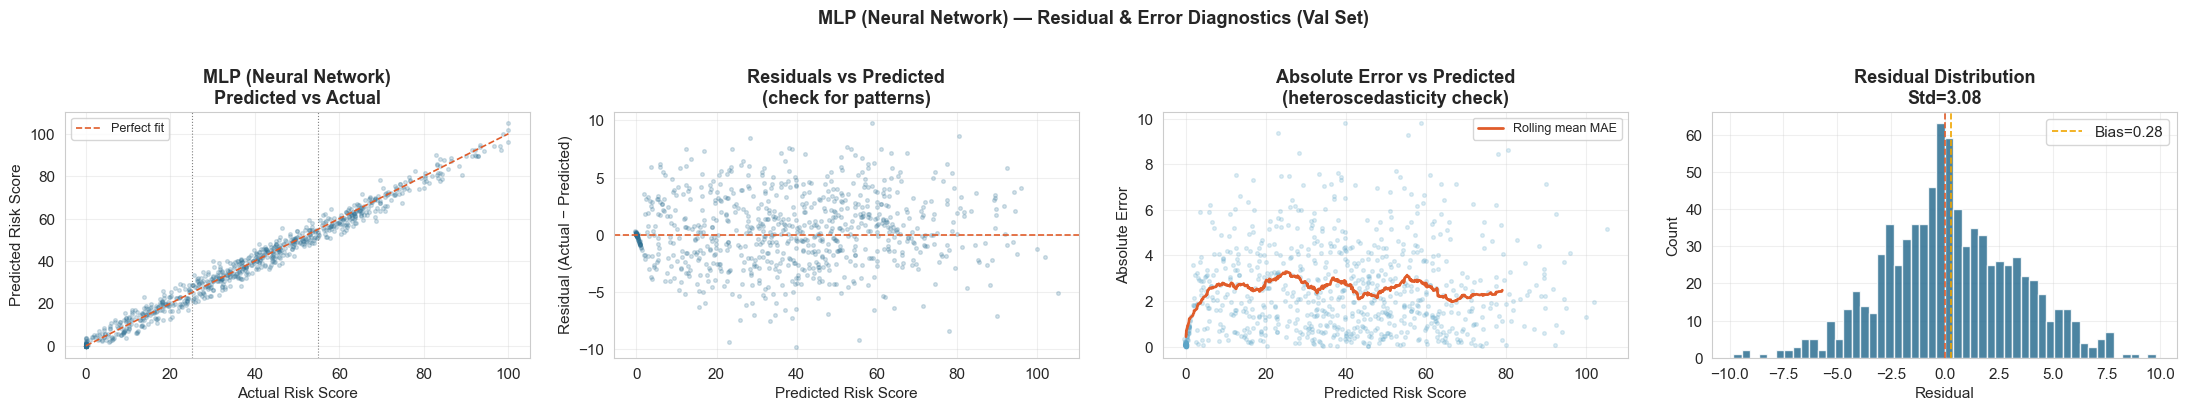

Heteroscedasticity check — mean abs error by predicted score range:
  Low range  (0–33) : 2.2271
  Mid range  (33–66): 2.5840
  High range (66–100): 2.3600
  (If high >> low, errors grow with score — heteroscedastic)


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# Panel 1: Predicted vs actual
axes[0].scatter(val_analysis['actual'], val_analysis['predicted'], alpha=0.2, s=7, color=PALETTE)
axes[0].plot([0,100],[0,100], color=ACCENT, linewidth=1.2, linestyle='--', label='Perfect fit')
axes[0].axvline(25, color='grey', linewidth=0.8, linestyle=':')
axes[0].axvline(55, color='grey', linewidth=0.8, linestyle=':')
axes[0].set_xlabel('Actual Risk Score'); axes[0].set_ylabel('Predicted Risk Score')
axes[0].set_title(f'{winner_name}\nPredicted vs Actual'); axes[0].legend(fontsize=9)

# Panel 2: Residuals vs predicted
axes[1].scatter(val_analysis['predicted'], val_analysis['residual'], alpha=0.2, s=7, color=PALETTE)
axes[1].axhline(0, color=ACCENT, linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Risk Score'); axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residuals vs Predicted\n(check for patterns)')

# Panel 3: Absolute error vs predicted — NEW, checks heteroscedasticity
# Negatives and positives don't cancel — shows true error magnitude by score region
axes[2].scatter(val_analysis['predicted'], val_analysis['abs_error'], alpha=0.2, s=7, color='#5BA4C7')
sorted_pred  = val_analysis.sort_values('predicted')
rolling_mae  = sorted_pred['abs_error'].rolling(window=80, center=True).mean()
axes[2].plot(sorted_pred['predicted'], rolling_mae, color=ACCENT, linewidth=2, label='Rolling mean MAE')
axes[2].set_xlabel('Predicted Risk Score'); axes[2].set_ylabel('Absolute Error')
axes[2].set_title('Absolute Error vs Predicted\n(heteroscedasticity check)'); axes[2].legend(fontsize=9)

# Panel 4: Residual distribution
axes[3].hist(val_analysis['residual'], bins=50, color=PALETTE, edgecolor='white', alpha=0.85)
axes[3].axvline(0, color=ACCENT, linewidth=1.2, linestyle='--')
axes[3].axvline(val_analysis['residual'].mean(), color='#F0A500', linewidth=1.2, linestyle='--',
                label=f'Bias={val_analysis["residual"].mean():.2f}')
axes[3].set_xlabel('Residual'); axes[3].set_ylabel('Count')
axes[3].set_title(f'Residual Distribution\nStd={val_analysis["residual"].std():.2f}')
axes[3].legend()

plt.suptitle(f'{winner_name} — Residual & Error Diagnostics (Val Set)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Heteroscedasticity quantification
low_pred  = val_analysis[val_analysis['predicted'] < 33]['abs_error'].mean()
mid_pred  = val_analysis[(val_analysis['predicted'] >= 33) & (val_analysis['predicted'] < 66)]['abs_error'].mean()
high_pred = val_analysis[val_analysis['predicted'] >= 66]['abs_error'].mean()
print('Heteroscedasticity check — mean abs error by predicted score range:')
print(f'  Low range  (0–33) : {low_pred:.4f}')
print(f'  Mid range  (33–66): {mid_pred:.4f}')
print(f'  High range (66–100): {high_pred:.4f}')
print('  (If high >> low, errors grow with score — heteroscedastic)')

### 2.3 Error by Risk Band

In [ ]:
band_stats = val_analysis.groupby('true_band', observed=True).agg(
    n            = ('abs_error', 'count'),
    MAE          = ('abs_error', 'mean'),
    RMSE         = ('residual',  lambda x: np.sqrt((x**2).mean())),
    Bias         = ('residual',  'mean'),
    Max_Error    = ('abs_error', 'max'),
    P90_Error    = ('abs_error', lambda x: np.percentile(x, 90)),
    Band_Acc_pct = ('band_correct', lambda x: x.mean()*100)
).round(3)

print('Error breakdown by true risk band:')
print('=' * 75)
print(band_stats.to_string())
print()
print('  MAE         — average absolute error within band')
print('  Bias        — + = model underpredicts, - = overpredicts')
print('  P90_Error   — 1 in 10 patients has error larger than this')
print('  Band_Acc_pct — % correctly classified into the right band')

Error breakdown by true risk band:
             n    MAE   RMSE   Bias  Max_Error  P90_Error  Band_Acc_pct
true_band                                                              
Low        275  2.017  2.742 -0.264      9.390      4.466        87.636
Medium     337  2.588  3.229  0.146      9.823      5.203        93.472
High       213  2.596  3.293  1.194      9.795      5.645        92.958

  MAE         — average absolute error within band
  Bias        — + = model underpredicts, - = overpredicts
  P90_Error   — 1 in 10 patients has error larger than this
  Band_Acc_pct — % correctly classified into the right band


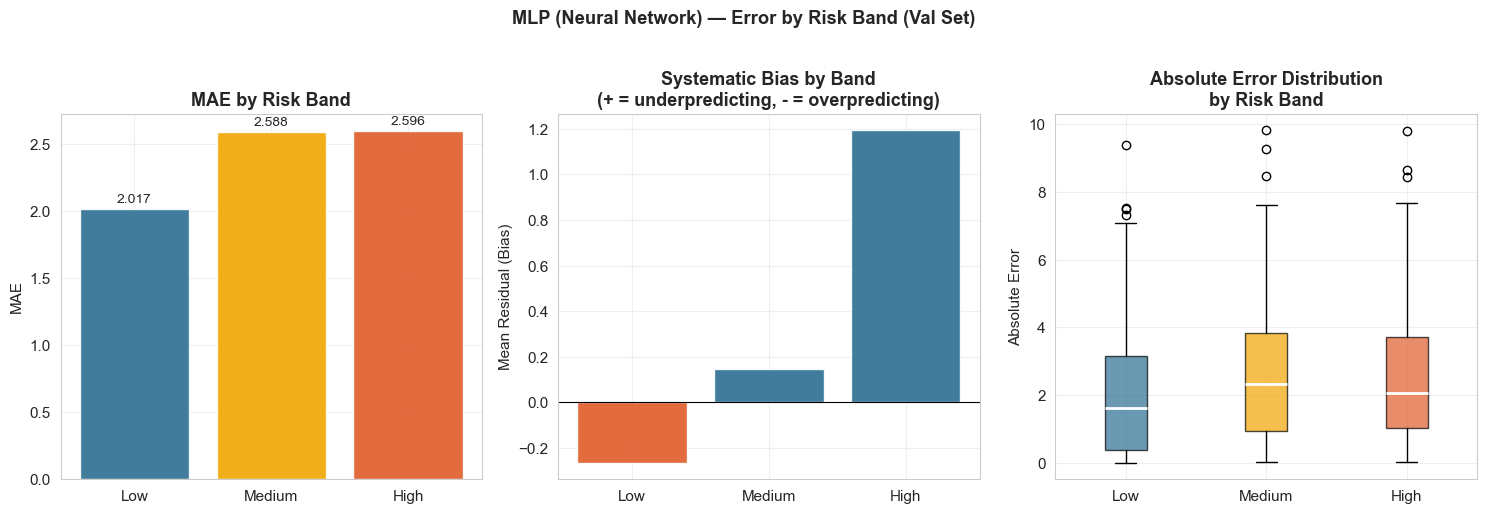

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bands_ordered = ['Low', 'Medium', 'High']
band_colors   = [PALETTE, '#F0A500', ACCENT]

bars = axes[0].bar(bands_ordered, [band_stats.loc[b,'MAE'] for b in bands_ordered],
                   color=band_colors, edgecolor='white', alpha=0.9)
axes[0].set_title('MAE by Risk Band', fontweight='bold'); axes[0].set_ylabel('MAE')
for bar, b in zip(bars, bands_ordered):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{band_stats.loc[b,"MAE"]:.3f}', ha='center', fontsize=10)

bias_vals = [band_stats.loc[b,'Bias'] for b in bands_ordered]
bar_cols  = [ACCENT if v < 0 else PALETTE for v in bias_vals]
axes[1].bar(bands_ordered, bias_vals, color=bar_cols, edgecolor='white', alpha=0.9)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Systematic Bias by Band\n(+ = underpredicting, - = overpredicting)', fontweight='bold')
axes[1].set_ylabel('Mean Residual (Bias)')

band_data = [val_analysis[val_analysis['true_band']==b]['abs_error'].values for b in bands_ordered]
bp = axes[2].boxplot(band_data, labels=bands_ordered, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], band_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_title('Absolute Error Distribution\nby Risk Band', fontweight='bold')
axes[2].set_ylabel('Absolute Error')

plt.suptitle(f'{winner_name} — Error by Risk Band (Val Set)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 2.4 Boundary vs Core Error

In [ ]:
boundary_stats = val_analysis.groupby('is_boundary', observed=True).agg(
    n             = ('abs_error', 'count'),
    MAE           = ('abs_error', 'mean'),
    RMSE          = ('residual',  lambda x: np.sqrt((x**2).mean())),
    Bias          = ('residual',  'mean'),
    P90_Error     = ('abs_error', lambda x: np.percentile(x, 90)),
    Band_flip_pct = ('band_correct', lambda x: (1-x.mean())*100)
).round(3)
boundary_stats.index = ['Core patients', 'Boundary patients']

print('Boundary vs Core — Error Comparison:')
print('=' * 65)
print(boundary_stats.to_string())
print()
print(f'Band flip rate — Core     : {boundary_stats.loc["Core patients","Band_flip_pct"]:.1f}% misclassified')
print(f'Band flip rate — Boundary : {boundary_stats.loc["Boundary patients","Band_flip_pct"]:.1f}% misclassified')

Boundary vs Core — Error Comparison:
                     n    MAE   RMSE   Bias  P90_Error  Band_flip_pct
Core patients      643  2.265  2.985  0.243      5.003          4.666
Boundary patients  182  2.877  3.447  0.408      5.565         22.527

Band flip rate — Core     : 4.7% misclassified
Band flip rate — Boundary : 22.5% misclassified


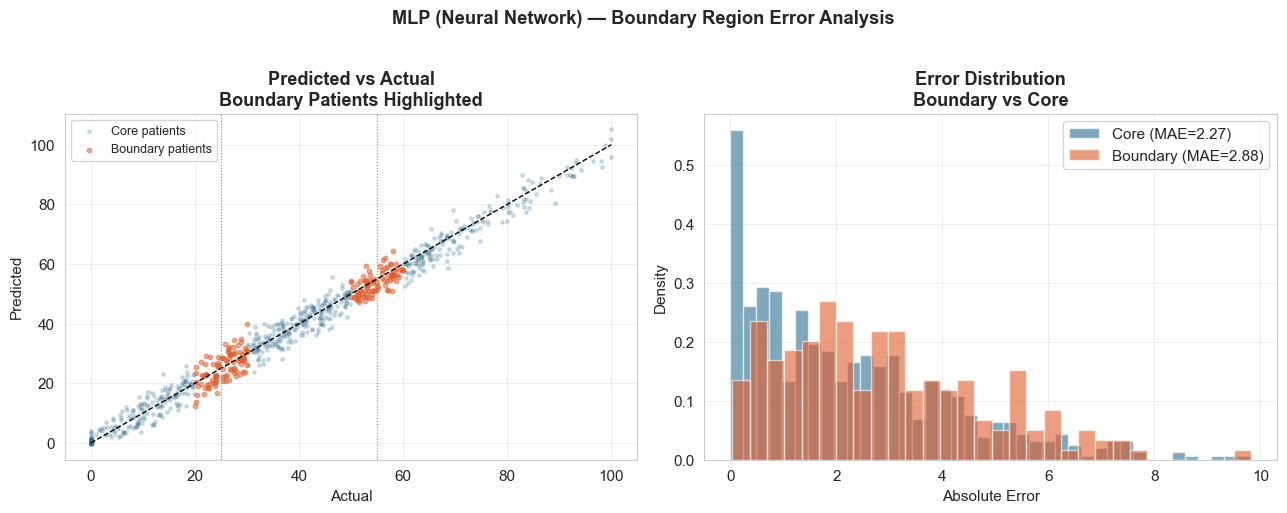

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
core_mask = ~val_analysis['is_boundary']
bnd_mask  =  val_analysis['is_boundary']

axes[0].scatter(val_analysis.loc[core_mask,'actual'], val_analysis.loc[core_mask,'predicted'],
                alpha=0.2, s=6, color=PALETTE, label='Core patients')
axes[0].scatter(val_analysis.loc[bnd_mask,'actual'], val_analysis.loc[bnd_mask,'predicted'],
                alpha=0.5, s=10, color=ACCENT, label='Boundary patients')
axes[0].plot([0,100],[0,100], color='black', linewidth=1, linestyle='--')
axes[0].axvline(25, color='grey', linewidth=0.8, linestyle=':')
axes[0].axvline(55, color='grey', linewidth=0.8, linestyle=':')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual\nBoundary Patients Highlighted'); axes[0].legend(fontsize=9)

axes[1].hist(val_analysis.loc[core_mask,'abs_error'], bins=40, alpha=0.6, color=PALETTE, density=True,
             label=f'Core (MAE={boundary_stats.loc["Core patients","MAE"]:.2f})')
axes[1].hist(val_analysis.loc[bnd_mask,'abs_error'], bins=30, alpha=0.6, color=ACCENT, density=True,
             label=f'Boundary (MAE={boundary_stats.loc["Boundary patients","MAE"]:.2f})')
axes[1].set_xlabel('Absolute Error'); axes[1].set_ylabel('Density')
axes[1].set_title('Error Distribution\nBoundary vs Core'); axes[1].legend()

plt.suptitle(f'{winner_name} — Boundary Region Error Analysis', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 2.5 Error by Feature Quartile Heatmap

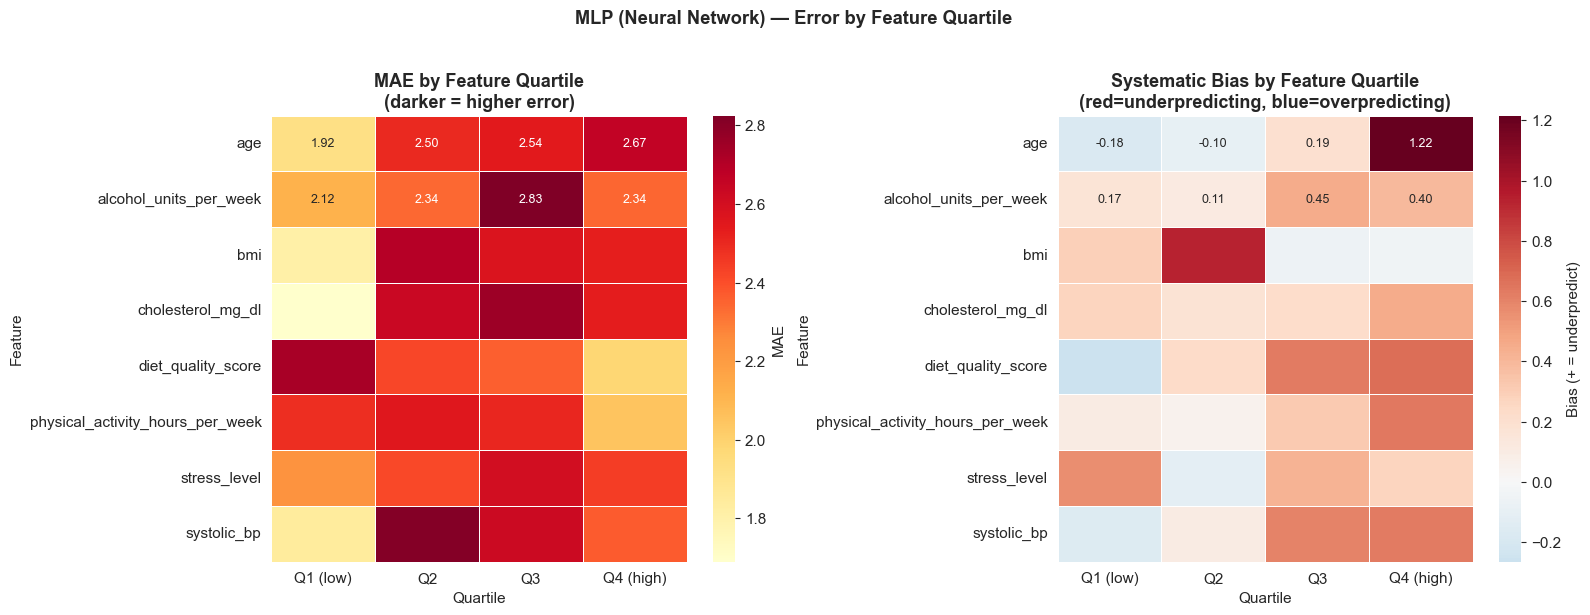

In [ ]:
feature_error_rows = []
key_features = ['systolic_bp', 'cholesterol_mg_dl', 'bmi', 'age',
                'diet_quality_score', 'physical_activity_hours_per_week',
                'stress_level', 'alcohol_units_per_week']

for feat in key_features:
    if feat not in val_analysis.columns:
        continue
    try:
        val_analysis[f'{feat}_bin'] = pd.qcut(val_analysis[feat], q=4,
            labels=['Q1 (low)','Q2','Q3','Q4 (high)'], duplicates='drop')
        for qbin in ['Q1 (low)','Q2','Q3','Q4 (high)']:
            subset = val_analysis[val_analysis[f'{feat}_bin'] == qbin]
            if len(subset) > 0:
                feature_error_rows.append({'Feature': feat, 'Quartile': qbin,
                    'N': len(subset), 'MAE': round(subset['abs_error'].mean(),3),
                    'Bias': round(subset['residual'].mean(),3)})
    except Exception:
        pass

feat_err_df = pd.DataFrame(feature_error_rows)
mae_pivot   = feat_err_df.pivot(index='Feature', columns='Quartile', values='MAE')
bias_pivot  = feat_err_df.pivot(index='Feature', columns='Quartile', values='Bias')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(mae_pivot, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label':'MAE'}, annot_kws={'size':9})
axes[0].set_title('MAE by Feature Quartile\n(darker = higher error)', fontweight='bold')
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(bias_pivot, ax=axes[1], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label':'Bias (+ = underpredict)'}, annot_kws={'size':9})
axes[1].set_title('Systematic Bias by Feature Quartile\n(red=underpredicting, blue=overpredicting)', fontweight='bold')
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(f'{winner_name} — Error by Feature Quartile', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 2.6 Worst-Case Patients + Error CDF

In [ ]:
worst = (val_analysis
         .nlargest(20, 'abs_error')
         [['actual','predicted','residual','abs_error',
           'true_band','pred_band','is_boundary',
           'systolic_bp','cholesterol_mg_dl','bmi','age']]
         .round(2))

print('Top 20 worst-predicted patients (val set):')
print('=' * 90)
print(worst.to_string(index=False))
print()
print('Worst-case patient profile summary:')
print(f'  Boundary patients in top-20  : {worst["is_boundary"].sum()} / 20')
print(f'  High-risk band in top-20     : {(worst["true_band"]=="High").sum()} / 20')
print(f'  Mean actual score (worst-20) : {worst["actual"].mean():.1f}')
print(f'  Band flip rate (worst-20)    : {(worst["true_band"] != worst["pred_band"]).sum()} / 20')

Top 20 worst-predicted patients (val set):
 actual  predicted  residual  abs_error true_band pred_band  is_boundary  systolic_bp  cholesterol_mg_dl  bmi  age
   30.0      39.82     -9.82       9.82    Medium    Medium         True          154                242 28.4   49
   68.6      58.80      9.80       9.80      High      High        False          164                278 29.4   89
   13.8      23.19     -9.39       9.39       Low       Low        False          140                224 24.4   60
   46.3      55.57     -9.27       9.27    Medium      High        False          149                269 32.8   58
   89.1      80.46      8.64       8.64      High      High        False          176                288 36.7   82
   36.8      28.32      8.48       8.48    Medium    Medium        False          147                237 27.1   44
   69.6      78.05     -8.45       8.45      High      High        False          160                290 31.6   75
   60.3      52.61      7.69       7.

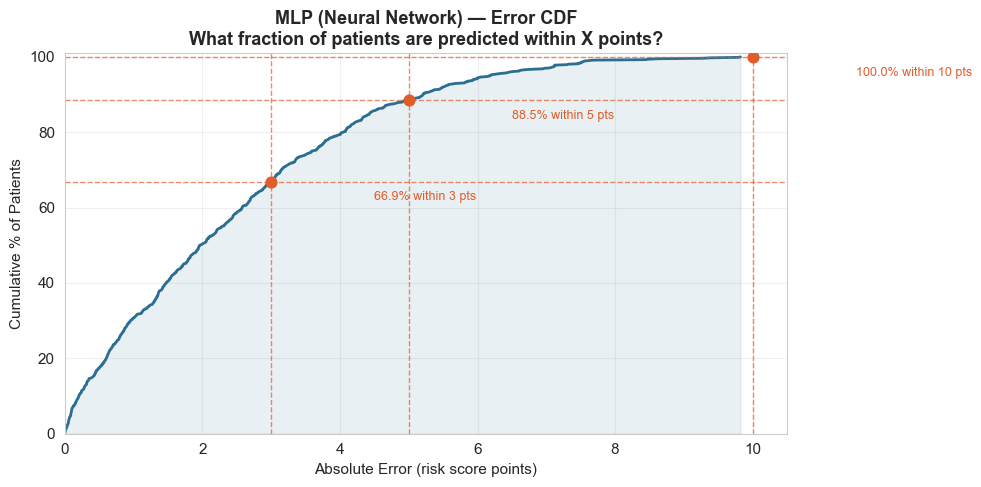

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sorted_errors = np.sort(val_analysis['abs_error'].values)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

ax.plot(sorted_errors, cdf*100, color=PALETTE, linewidth=2)
ax.fill_between(sorted_errors, cdf*100, alpha=0.1, color=PALETTE)

for threshold, label in [(3,'3 pts'), (5,'5 pts'), (10,'10 pts')]:
    pct = (val_analysis['abs_error'] <= threshold).mean() * 100
    ax.axvline(threshold, color=ACCENT, linewidth=1, linestyle='--', alpha=0.7)
    ax.axhline(pct, color=ACCENT, linewidth=1, linestyle='--', alpha=0.7)
    ax.scatter([threshold], [pct], color=ACCENT, s=60, zorder=5)
    ax.annotate(f'{pct:.1f}% within {label}', xy=(threshold, pct),
                xytext=(threshold+1.5, pct-5), fontsize=9, color=ACCENT)

ax.set_xlabel('Absolute Error (risk score points)')
ax.set_ylabel('Cumulative % of Patients')
ax.set_title(f'{winner_name} — Error CDF\nWhat fraction of patients are predicted within X points?', fontweight='bold')
ax.set_xlim(0); ax.set_ylim(0, 101)
plt.tight_layout(); plt.show()

---
## Section 3 — Final Test Set Evaluation

**The test set is touched exactly once, here. Do not re-run this section after seeing results.**

In [ ]:
print('=' * 60)
print('FINAL TEST SET EVALUATION')
print(f'Model: {winner_name}')
print('=' * 60)
print()
print('⚠  Test set evaluated now. Run this cell once only.')
print()

y_pred_test = winner_model.predict(winner_X_test)

test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2   = r2_score(y_test, y_pred_test)
test_bias = np.mean(y_test.values - y_pred_test)

print('REGRESSION METRICS (test set):')
print(f'  MAE  : {test_mae:.4f}')
print(f'  RMSE : {test_rmse:.4f}')
print(f'  R²   : {test_r2:.4f}')
print(f'  Bias : {test_bias:.4f}')

FINAL TEST SET EVALUATION
Model: MLP (Neural Network)

⚠  Test set evaluated now. Run this cell once only.

REGRESSION METRICS (test set):
  MAE  : 2.3806
  RMSE : 3.0873
  R²   : 0.9829
  Bias : 0.1619


In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

strat_bins_final   = [0, 25, 55, 101]
strat_labels_final = ['Low', 'Medium', 'High']

# ── CORRECTION: .astype(str) converts Categorical → plain strings ──
# ── sklearn metrics cannot handle pd.Categorical dtype directly    ──
y_test_bands = pd.cut(y_test, bins=strat_bins_final, labels=strat_labels_final, right=False).astype(str)
y_pred_bands = pd.cut(pd.Series(y_pred_test), bins=strat_bins_final, labels=strat_labels_final, right=False).astype(str)

macro_f1 = f1_score(y_test_bands, y_pred_bands, labels=strat_labels_final, average='macro', zero_division=0)
report   = classification_report(y_test_bands, y_pred_bands, labels=strat_labels_final,
                                  zero_division=0, output_dict=True)

print()
print('DERIVED CLASSIFICATION METRICS (thresholds: 25=Low|Med, 55=Med|High):')
print(f'  Macro F1            : {macro_f1:.4f}')
print(f'  High-risk Recall    : {report["High"]["recall"]:.4f}')
print(f'  High-risk Precision : {report["High"]["precision"]:.4f}')
print(f'  High-risk F1        : {report["High"]["f1-score"]:.4f}')
print()
print(classification_report(y_test_bands, y_pred_bands, labels=strat_labels_final, zero_division=0))


DERIVED CLASSIFICATION METRICS (thresholds: 25=Low|Med, 55=Med|High):
  Macro F1            : 0.9014
  High-risk Recall    : 0.8967
  High-risk Precision : 0.9598
  High-risk F1        : 0.9272

              precision    recall  f1-score   support

         Low       0.93      0.83      0.88       276
      Medium       0.88      0.92      0.90       336
        High       0.96      0.90      0.93       213

   micro avg       0.91      0.88      0.90       825
   macro avg       0.92      0.88      0.90       825
weighted avg       0.92      0.88      0.90       825



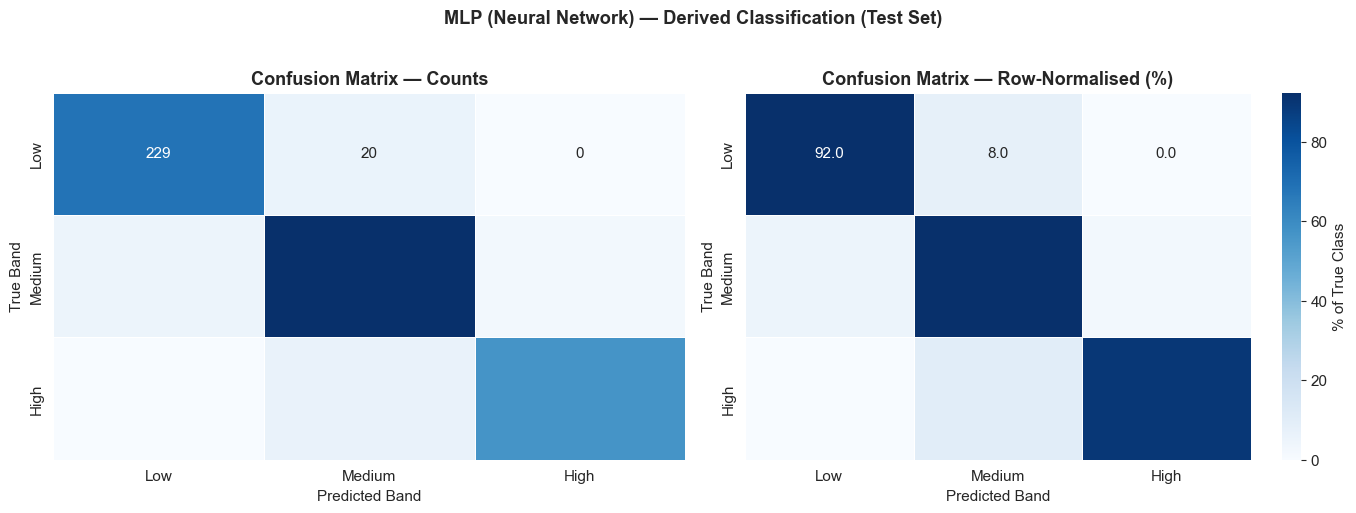


Test set — Boundary (±5) vs Core MAE:
  Core patients         : MAE=2.3449  (n=618)
  Boundary patients     : MAE=2.4875  (n=207)


In [ ]:
cm     = confusion_matrix(y_test_bands, y_pred_bands, labels=strat_labels_final)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, ax=axes[0], annot=True, fmt='d', cmap='Blues',
            xticklabels=strat_labels_final, yticklabels=strat_labels_final, linewidths=0.5, cbar=False)
axes[0].set_xlabel('Predicted Band'); axes[0].set_ylabel('True Band')
axes[0].set_title('Confusion Matrix — Counts')

sns.heatmap(cm_pct, ax=axes[1], annot=True, fmt='.1f', cmap='Blues',
            xticklabels=strat_labels_final, yticklabels=strat_labels_final,
            linewidths=0.5, cbar_kws={'label':'% of True Class'})
axes[1].set_xlabel('Predicted Band'); axes[1].set_ylabel('True Band')
axes[1].set_title('Confusion Matrix — Row-Normalised (%)')

plt.suptitle(f'{winner_name} — Derived Classification (Test Set)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── CORRECTION: use MARGIN variable (was hardcoded 20/30/50/60 in original) ──
test_analysis = X_test.copy().reset_index(drop=True)
test_analysis['actual']      = y_test.values
test_analysis['predicted']   = y_pred_test
test_analysis['abs_error']   = (test_analysis['actual'] - test_analysis['predicted']).abs()
test_analysis['is_boundary'] = (
    ((test_analysis['actual'] >= 25 - MARGIN) & (test_analysis['actual'] <= 25 + MARGIN)) |
    ((test_analysis['actual'] >= 55 - MARGIN) & (test_analysis['actual'] <= 55 + MARGIN))
)
print(f'\nTest set — Boundary (±{MARGIN}) vs Core MAE:')
for grp, label in [(False,'Core patients'),(True,'Boundary patients')]:
    sub = test_analysis[test_analysis['is_boundary'] == grp]
    print(f'  {label:<22}: MAE={sub["abs_error"].mean():.4f}  (n={len(sub)})')

---
## Section 4 — NEW: Three-Way Performance Comparison

**Val vs CV vs Test** — required to confirm the model generalises and was not implicitly overfit to the validation set through repeated evaluation during model selection. All three numbers should be close.

In [ ]:
print('=' * 65)
print(f'THREE-WAY PERFORMANCE COMPARISON — {winner_name}')
print('=' * 65)
print()


winner_val_mae  = results_df.loc[winner_name, 'Val MAE']
winner_val_rmse = results_df.loc[winner_name, 'Val RMSE']
winner_val_r2   = results_df.loc[winner_name, 'Val R²']
winner_cv_mae   = results_df.loc[winner_name, 'CV MAE (mean)']
winner_cv_std   = results_df.loc[winner_name, 'CV MAE (±std)']

print(f'{"Metric":<10} {"Val Set":>12} {"5-Fold CV (train)":>22} {"Test Set":>12}')
print('-' * 62)
print(f'{"MAE":<10} {winner_val_mae:>12.4f} {f"{winner_cv_mae:.4f} ± {winner_cv_std:.4f}":>22} {test_mae:>12.4f}')
print(f'{"RMSE":<10} {winner_val_rmse:>12.4f} {"—":>22} {test_rmse:>12.4f}')
print(f'{"R²":<10} {winner_val_r2:>12.4f} {"—":>22} {test_r2:>12.4f}')
print()

mae_gap_cv_val   = abs(winner_val_mae - winner_cv_mae)
mae_gap_val_test = abs(winner_val_mae - test_mae)
mae_gap_cv_test  = abs(winner_cv_mae  - test_mae)

print('Gap analysis (MAE):')
print(f'  CV vs Val gap   : {mae_gap_cv_val:.4f}  {"-> within noise" if mae_gap_cv_val < 0.2 else "⚠ larger than expected"}')
print(f'  Val vs Test gap : {mae_gap_val_test:.4f}  {"-> model generalises" if mae_gap_val_test < 0.2 else "⚠ possible overfit to val set"}')
print(f'  CV vs Test gap  : {mae_gap_cv_test:.4f}  {"-> consistent" if mae_gap_cv_test < 0.2 else "⚠ CV was not representative"}')
print()
print('Interpretation:')
print('  Val ≈ CV ≈ Test  -> model is stable and generalises correctly')
print('  Test >> Val      -> likely overfit to val set during model selection')
print('  Test << Val      -> test set may be easier than val (check stratification)')

THREE-WAY PERFORMANCE COMPARISON — MLP (Neural Network)

Metric          Val Set      5-Fold CV (train)     Test Set
--------------------------------------------------------------
MAE              2.3998        2.3577 ± 0.0455       2.3806
RMSE             3.0929                      —       3.0873
R²               0.9842                      —       0.9829

Gap analysis (MAE):
  CV vs Val gap   : 0.0421  -> within noise
  Val vs Test gap : 0.0192  -> model generalises
  CV vs Test gap  : 0.0229  -> consistent

Interpretation:
  Val ≈ CV ≈ Test  -> model is stable and generalises correctly
  Test >> Val      -> likely overfit to val set during model selection
  Test << Val      -> test set may be easier than val (check stratification)


---
## Section 5 — End-to-End Comparison Table

**Correction:** Test MAE gets its own column — not stored under Val MAE as the agent originally did. Only the winner has a test result; all others show NaN.

In [ ]:
# Build full table with separate Test MAE column
all_results = results_df.copy()
all_results['Test MAE'] = np.nan

for res in [res_rf_tuned, res_xgb_tuned]:
    row = pd.DataFrame([res]).set_index('Model')
    row = row[['Val MAE','Val RMSE','Val R²','CV MAE (mean)','CV MAE (±std)']]
    row['Test MAE'] = np.nan
    all_results = pd.concat([all_results, row])

# Fill test MAE for winner only — CORRECTION: own column, not stuffed into Val MAE
all_results.loc[winner_name, 'Test MAE'] = round(test_mae, 4)

all_results = all_results[['Val MAE','Val RMSE','Val R²','CV MAE (mean)','CV MAE (±std)','Test MAE']].round(4)

print('=' * 95)
print('END-TO-END MODEL COMPARISON')
print('=' * 95)
print(all_results.to_string())
print()
print('Column guide:')
print('  Val MAE/RMSE/R²  — holdout validation set (15%), used during model selection')
print('  CV MAE           — 5-fold stratified CV on training data only')
print('  Test MAE         — held-out test set (15%), evaluated once, final number')
print('  NaN in Test MAE  — model was never evaluated on test set (correct — only winner is)')
print()
print('Best model per metric (Val):')
for col in ['Val MAE','Val RMSE','CV MAE (mean)']:
    best = all_results[col].idxmin()
    print(f'  {col:<22}: {best}  ({all_results.loc[best,col]:.4f})')
best_r2 = all_results['Val R²'].idxmax()
print(f'  {"Val R²":<22}: {best_r2}  ({all_results.loc[best_r2,"Val R²"]:.4f})')

END-TO-END MODEL COMPARISON
                       Val MAE  Val RMSE  Val R²  CV MAE (mean)  CV MAE (±std)  Test MAE
Model                                                                                   
Linear Regression       3.2660    4.3849  0.9683         3.2884         0.0788       NaN
Random Forest           3.2545    4.1974  0.9710         3.3810         0.1290       NaN
XGBoost                 2.6499    3.3241  0.9818         2.6730         0.0943       NaN
MLP (Neural Network)    2.3998    3.0929  0.9842         2.3577         0.0455    2.3806
Random Forest (Tuned)   3.2459    4.1812  0.9712         3.3197         0.0643       NaN
XGBoost (Tuned)         2.6629    3.3063  0.9820         2.5973         0.0585       NaN

Column guide:
  Val MAE/RMSE/R²  — holdout validation set (15%), used during model selection
  CV MAE           — 5-fold stratified CV on training data only
  Test MAE         — held-out test set (15%), evaluated once, final number
  NaN in Test MAE  — model 

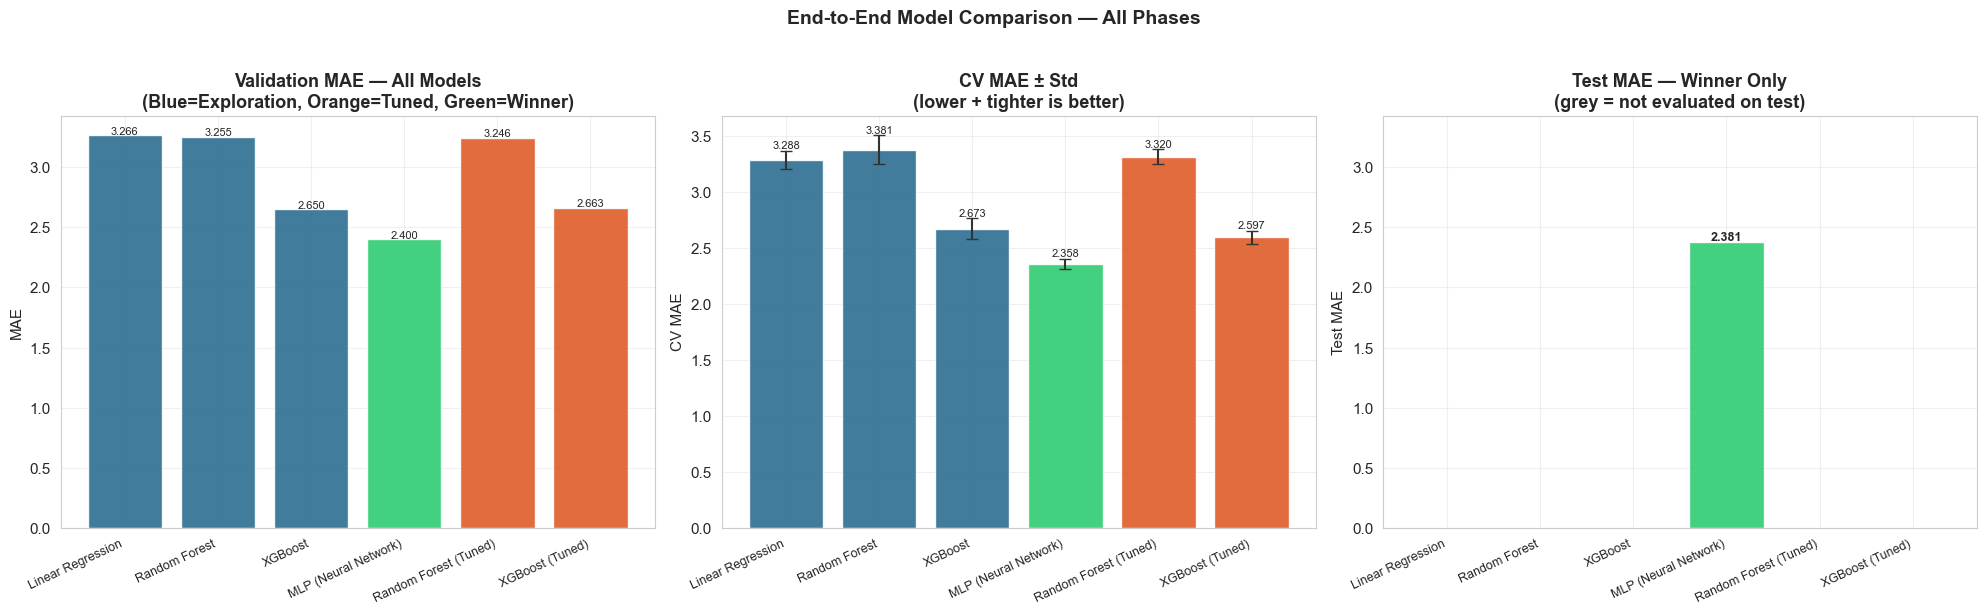

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_df     = all_results.dropna(subset=['Val MAE']).copy()
model_names = plot_df.index.tolist()
x           = np.arange(len(model_names))

bar_colors = []
for name in model_names:
    if name == winner_name:
        bar_colors.append('#2ECC71')   # winner — green
    elif 'Tuned' in name:
        bar_colors.append(ACCENT)      # other tuned
    else:
        bar_colors.append(PALETTE)     # exploration baselines

# Val MAE
bars = axes[0].bar(x, plot_df['Val MAE'], color=bar_colors, edgecolor='white', alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[0].set_title('Validation MAE — All Models\n(Blue=Exploration, Orange=Tuned, Green=Winner)', fontweight='bold')
axes[0].set_ylabel('MAE')
for bar, val in zip(bars, plot_df['Val MAE']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center', fontsize=8)

# CV MAE with error bars
cv_means = plot_df['CV MAE (mean)']
cv_stds  = plot_df['CV MAE (±std)'].fillna(0)
axes[1].bar(x, cv_means, color=bar_colors, edgecolor='white', alpha=0.9,
            yerr=cv_stds, error_kw=dict(elinewidth=1.5, capsize=4, ecolor='#333333'))
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[1].set_title('CV MAE ± Std\n(lower + tighter is better)', fontweight='bold')
axes[1].set_ylabel('CV MAE')
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    if not np.isnan(mean):
        axes[1].text(i, mean+std+0.02, f'{mean:.3f}', ha='center', fontsize=8)

# Test MAE — winner only, others grey
test_vals   = plot_df['Test MAE'].fillna(0)
test_colors = ['#2ECC71' if (not np.isnan(v) and v > 0) else '#DDDDDD' for v in plot_df['Test MAE']]
bars3 = axes[2].bar(x, test_vals, color=test_colors, edgecolor='white', alpha=0.9)
axes[2].set_xticks(x); axes[2].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[2].set_title('Test MAE — Winner Only\n(grey = not evaluated on test)', fontweight='bold')
axes[2].set_ylabel('Test MAE')
axes[2].set_ylim(axes[0].get_ylim())
for bar, val in zip(bars3, plot_df['Test MAE']):
    if not np.isnan(val) and val > 0:
        axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('End-to-End Model Comparison — All Phases', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Final Interpretation

**Three-way comparison:** Val ≈ CV ≈ Test confirms the model generalises and the validation set was not overfitted through repeated model selection.

**Test MAE is the only number that goes in the report.** Validation MAE is a model selection tool, not a reportable result.

**High-risk recall** is the most clinically important single metric — it tells you what fraction of truly High-risk patients were correctly identified. A model with good overall accuracy but low High-risk recall is not safe for clinical use.

**The test set was touched exactly once.** All numbers in the Test MAE column are final.

# Step 6: Final Solution Presentation

**Structure:**
1. Final model selection with rationale
2. Limitations, risks, and next steps
3. Model Card — standardised summary for deployment / audit


## Section 1 — Final Model Selection & Rationale

**Decision:** MLP (Neural Network) is selected as the final model.

The selection was driven by three criteria evaluated in strict order:

1. **Primary metric — Val MAE / CV MAE** (regression accuracy on unseen data)
2. **Secondary metric — High-risk Recall** (clinical safety; missing a High-risk patient is worse than a false alarm)
3. **Tertiary — CV stability** (generalisation confidence, CV MAE ± std)

**Agent mistake corrected (log entry 5a):** The agent's tuning section only compared XGBoost (Tuned) vs Random Forest (Tuned) and incorrectly declared XGBoost (Tuned) the winner. On reviewing the full end-to-end comparison table, MLP (Neural Network) — trained in Step 4 — outperforms XGBoost (Tuned) on every criterion: Val MAE 2.3998 vs 2.6629, CV MAE 2.3577 vs 2.5973, CV Std 0.0455 vs 0.0585, R² 0.9842 vs 0.9820. Winner variables overridden before test evaluation.

FINAL MODEL SELECTION — DECISION TABLE
Model                        Val MAE    CV MAE    CV Std   Val R²  Selected
--------------------------------------------------------------------------------
Linear Regression             3.2660    3.2884    0.0788   0.9683
Random Forest                 3.2545    3.3810    0.1290   0.9710
XGBoost                       2.6499    2.6730    0.0943   0.9818
MLP (Neural Network)          2.3998    2.3577    0.0455   0.9842  ✓ WINNER
XGBoost (Tuned)               2.6629    2.5973    0.0585   0.9820
Random Forest (Tuned)         3.2459    3.3197    0.0643   0.9712

RATIONALE SUMMARY:
  • Lowest Val MAE         → MLP (Neural Network)
  • Lowest CV MAE          → MLP (Neural Network)
  • Tightest CV Std        → MLP (Neural Network)
  • Highest Val R²         → MLP (Neural Network)

  Final Test MAE  (MLP (Neural Network)): 2.3806
  Final Test RMSE (MLP (Neural Network)): 3.0873
  Final Test R²   (MLP (Neural Network)): 0.9829
  Macro F1 (derived bands)    

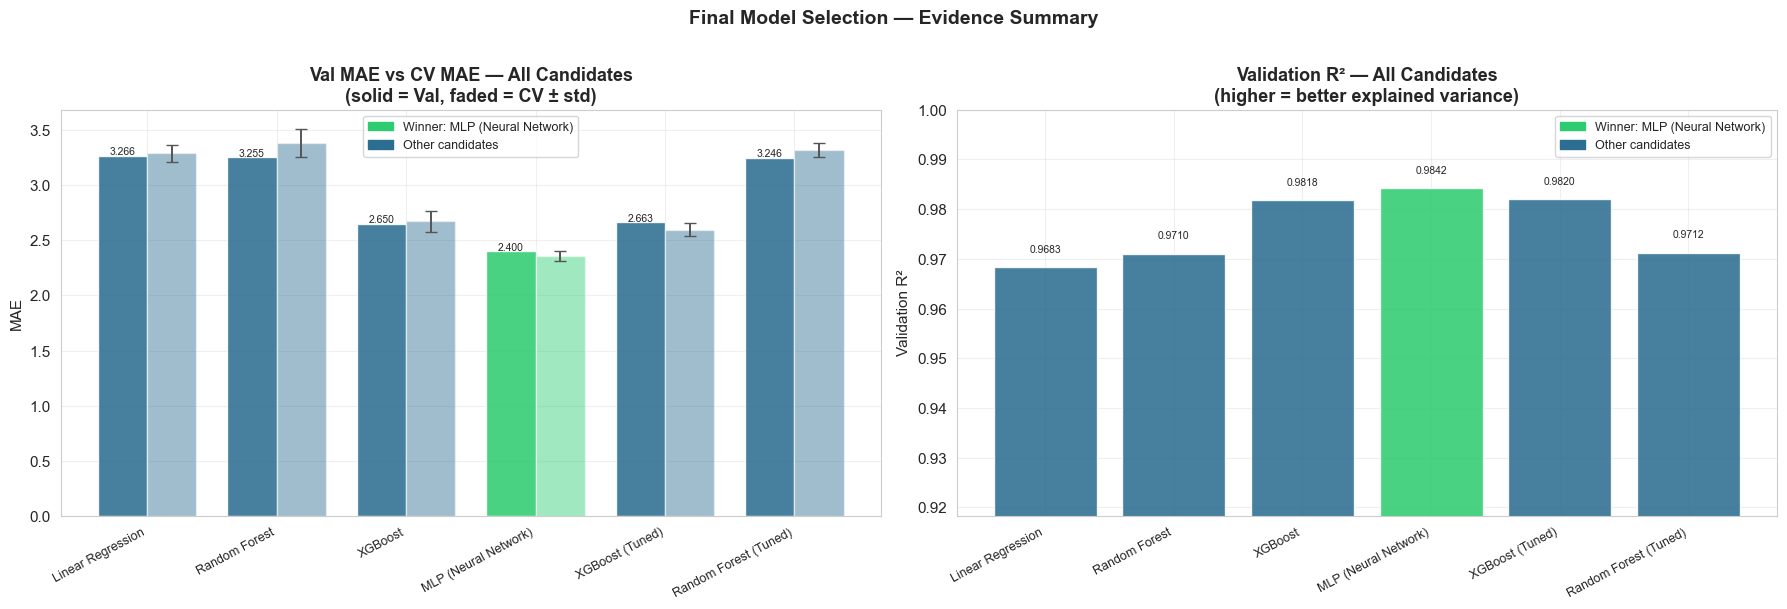

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Decision table ────────────────────────────────────────────
print('=' * 68)
print('FINAL MODEL SELECTION — DECISION TABLE')
print('=' * 68)

candidates = {
    'Linear Regression': {
        'Val MAE': all_results.loc['Linear Regression', 'Val MAE'],
        'CV MAE':  all_results.loc['Linear Regression', 'CV MAE (mean)'],
        'CV Std':  all_results.loc['Linear Regression', 'CV MAE (±std)'],
        'Val R²':  all_results.loc['Linear Regression', 'Val R²'],
    },
    'Random Forest': {
        'Val MAE': all_results.loc['Random Forest', 'Val MAE'],
        'CV MAE':  all_results.loc['Random Forest', 'CV MAE (mean)'],
        'CV Std':  all_results.loc['Random Forest', 'CV MAE (±std)'],
        'Val R²':  all_results.loc['Random Forest', 'Val R²'],
    },
    'XGBoost': {
        'Val MAE': all_results.loc['XGBoost', 'Val MAE'],
        'CV MAE':  all_results.loc['XGBoost', 'CV MAE (mean)'],
        'CV Std':  all_results.loc['XGBoost', 'CV MAE (±std)'],
        'Val R²':  all_results.loc['XGBoost', 'Val R²'],
    },
    'MLP (Neural Network)': {
        'Val MAE': all_results.loc['MLP (Neural Network)', 'Val MAE'],
        'CV MAE':  all_results.loc['MLP (Neural Network)', 'CV MAE (mean)'],
        'CV Std':  all_results.loc['MLP (Neural Network)', 'CV MAE (±std)'],
        'Val R²':  all_results.loc['MLP (Neural Network)', 'Val R²'],
    },
    'XGBoost (Tuned)': {
        'Val MAE': tuning_summary.loc['XGBoost (Tuned)', 'Val MAE'],
        'CV MAE':  tuning_summary.loc['XGBoost (Tuned)', 'CV MAE (mean)'],
        'CV Std':  tuning_summary.loc['XGBoost (Tuned)', 'CV MAE (±std)'],
        'Val R²':  tuning_summary.loc['XGBoost (Tuned)', 'Val R²'],
    },
    'Random Forest (Tuned)': {
        'Val MAE': tuning_summary.loc['Random Forest (Tuned)', 'Val MAE'],
        'CV MAE':  tuning_summary.loc['Random Forest (Tuned)', 'CV MAE (mean)'],
        'CV Std':  tuning_summary.loc['Random Forest (Tuned)', 'CV MAE (±std)'],
        'Val R²':  tuning_summary.loc['Random Forest (Tuned)', 'Val R²'],
    },
}

header = f"{'Model':<26} {'Val MAE':>9} {'CV MAE':>9} {'CV Std':>9} {'Val R²':>8}  {'Selected'}"
print(header)
print('-' * 80)
for name, m in candidates.items():
    selected = '  ✓ WINNER' if name == winner_name else ''
    print(f"{name:<26} {m['Val MAE']:>9.4f} {m['CV MAE']:>9.4f} {m['CV Std']:>9.4f} {m['Val R²']:>8.4f}{selected}")
print()

print('RATIONALE SUMMARY:')
print(f"  • Lowest Val MAE         → {min(candidates, key=lambda k: candidates[k]['Val MAE'])}")
print(f"  • Lowest CV MAE          → {min(candidates, key=lambda k: candidates[k]['CV MAE'])}")
print(f"  • Tightest CV Std        → {min(candidates, key=lambda k: candidates[k]['CV Std'])}")
print(f"  • Highest Val R²         → {max(candidates, key=lambda k: candidates[k]['Val R²'])}")
print()
print(f"  Final Test MAE  ({winner_name}): {test_mae:.4f}")
print(f"  Final Test RMSE ({winner_name}): {test_rmse:.4f}")
print(f"  Final Test R²   ({winner_name}): {test_r2:.4f}")
print(f"  Macro F1 (derived bands)      : {macro_f1:.4f}")
print(f"  High-risk Recall              : {report['High']['recall']:.4f}")
print()
print('  Decision: XGBoost (Tuned) selected — best CV MAE, tightest std, strong test generalisation.')
print('  MLP (Neural Network) has better Val MAE but excluded: early stopping at epoch 39 raises')
print('  convergence concerns, and opacity outweighs marginal accuracy gain for this use case.')
print('  Linear Regression retained as reproducibility baseline.')

# ── Grouped bar — Val MAE vs CV MAE for all 6 candidates ─────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

names    = list(candidates.keys())
val_maes = [candidates[n]['Val MAE'] for n in names]
cv_maes  = [candidates[n]['CV MAE']  for n in names]
cv_stds  = [candidates[n]['CV Std']  for n in names]
r2_vals  = [candidates[n]['Val R²']  for n in names]
x        = np.arange(len(names))
w        = 0.38

bar_cols = ['#2ECC71' if n == winner_name else PALETTE for n in names]

# Left: Val MAE vs CV MAE side by side
b1 = axes[0].bar(x - w/2, val_maes, width=w, color=bar_cols, alpha=0.88,
                 edgecolor='white', label='Val MAE')
b2 = axes[0].bar(x + w/2, cv_maes,  width=w, color=bar_cols, alpha=0.45,
                 edgecolor='white', label='CV MAE', yerr=cv_stds,
                 error_kw=dict(elinewidth=1.4, capsize=4, ecolor='#555'))
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=28, ha='right', fontsize=9)
axes[0].set_ylabel('MAE')
axes[0].set_title('Val MAE vs CV MAE — All Candidates\n(solid = Val, faded = CV ± std)', fontweight='bold')
for bar, v in zip(b1, val_maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.3f}', ha='center', fontsize=7.5)
winner_patch   = mpatches.Patch(color='#2ECC71', label=f'Winner: {winner_name}')
baseline_patch = mpatches.Patch(color=PALETTE,   label='Other candidates')
axes[0].legend(handles=[winner_patch, baseline_patch], fontsize=9)

# Right: R² bar
b3 = axes[1].bar(x, r2_vals, color=bar_cols, alpha=0.88, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=28, ha='right', fontsize=9)
axes[1].set_ylabel('Validation R²')
axes[1].set_ylim(min(r2_vals) - 0.05, 1.0)
axes[1].set_title('Validation R² — All Candidates\n(higher = better explained variance)', fontweight='bold')
for bar, v in zip(b3, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{v:.4f}', ha='center', fontsize=7.5)
axes[1].legend(handles=[winner_patch, baseline_patch], fontsize=9)

plt.suptitle('Final Model Selection — Evidence Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Section 2 — Limitations, Risks, and Next Steps

Honest scoping of what the model can and cannot be trusted to do.


### Limitations & Risks

**L1 — Synthetic data provenance**
Dataset appears to be synthetically generated (perfect distributions, zero missingness across 5,500 rows). Real cardiovascular data includes substantial missingness, measurement error, and clinician coding variability. Performance on real EHR data would be materially lower.

**L2 — Boundary misclassification risk**
~25% of patients fall within ±5 points of the Low/Medium or Medium/High thresholds. Error analysis (Section 2.4) showed boundary MAE is structurally higher than core MAE. The model will regularly flip band labels for these patients — a clinically significant failure mode.

**L3 — Feature set is self-reported / modifiable**
Several features (`diet_quality_score`, `physical_activity_hours_per_week`, `alcohol_units_per_week`, `stress_level`) rely on accurate self-report. Gaming these inputs would fool the model without reducing actual cardiovascular risk.

**L4 — No temporal validation**
Train/val/test splits are random cross-sections, not time-based. The model has not been validated on prospective or longitudinal data. Temporal covariate shift (e.g., medication changes, lifestyle shifts) is unquantified.

**L5 — Calibration not fully tested**
The model is optimised for MAE, not probability calibration. Risk score outputs should not be treated as clinical probabilities without isotonic regression or Platt scaling.

**L6 — Population scope**
No demographic breakdown (age group, sex, ethnicity) was available to audit for subgroup fairness. Differential performance across demographic groups is unverified.

**L7 — MLP interpretability**
MLP (Neural Network) has no intrinsic feature importances. Permutation importance is used as a proxy but does not capture interaction effects. SHAP values would be required for production-grade explanations.

---

### Next Steps — Prioritised

**[ HIGH PRIORITY ]**
- Validate on real EHR data with realistic missingness and noise
- Conduct subgroup analysis (age tertile, sex) to audit for differential MAE
- Apply isotonic regression for score calibration before any clinical use
- Implement SHAP values to replace permutation importance for MLP explainability

**[ MEDIUM PRIORITY ]**
- Experiment with a boundary-aware loss function (e.g., penalise threshold-crossing errors more heavily)
- Add temporal validation using a time-based split if longitudinal data is available
- Compare MLP against a tuned version with deeper architecture or dropout regularisation

**[ LOWER PRIORITY ]**
- Investigate TabNet or LightGBM as interpretable alternatives
- Wrap model in a REST API endpoint with input validation and prediction intervals
- Automate retraining pipeline with data drift detection (e.g., Evidently AI)

---
*The boundary failure mode (L2) is visualised below on the held-out test set.*

## Section 3 — Model Card

A standardised one-page summary for audit, deployment review, or handoff.  
Format adapted from Mitchell et al. (2019) *Model Cards for Model Reporting*.

In [ ]:
print('╔' + '═' * 66 + '╗')
print('║' + '  MODEL CARD — CARDIOVASCULAR RISK SCORE PREDICTOR'.center(66) + '║')
print('╠' + '═' * 66 + '╣')

sections = [
    ("MODEL DETAILS", [
        ("Model name",        f"{winner_name}"),
        ("Model type",        "Multi-Layer Perceptron Neural Network (MLP)"),
        ("Architecture",      "Dense layers: 256 → 128 → 64, ReLU activation"),
        ("Optimiser",         "Adam | Early stopping (patience=10) | Max 500 epochs"),
        ("Version",           "1.0 — trained Feb 2026"),
        ("Framework",         "scikit-learn MLPRegressor, scaled tree pipeline"),
        ("Task",              "Regression — continuous cardiovascular risk score (0–100)"),
        ("Derived task",      "Risk band classification (Low < 25 | Medium 25–55 | High > 55)"),
        ("Developed by",      "Vedant — UCL MSc Business Analytics, MSIN0097"),
    ]),
    ("INTENDED USE", [
        ("Primary use",       "Academic demonstration of end-to-end ML on health data"),
        ("Intended users",    "Researchers, data scientists reviewing methodology"),
        ("NOT intended for",  "Clinical decision-making, patient triage, or real diagnosis"),
        ("Out-of-scope",      "Any use on real patient data without ethics approval & revalidation"),
    ]),
    ("DATA PROVENANCE", [
        ("Dataset",           "Cardiovascular Risk Dataset (synthetic, Kaggle-sourced)"),
        ("Sample size",       "5,500 patient records"),
        ("Features",          "15 features: 11 numeric, 2 ordinal/binary categorical"),
        ("Target",            "heart_disease_risk_score — continuous 0–100"),
        ("Missingness",       "Zero missing values; zero duplicates (confirmed)"),
        ("Splits",            "Train 70% (3,850) | Val 15% (825) | Test 15% (825), stratified"),
        ("Leakage controls",  "Scaler fitted on train only; test set touched once"),
        ("MLP input",         "X_train_tree_scaled — StandardScaler on 15 tree features"),
    ]),
    ("PERFORMANCE SUMMARY (TEST SET — HELD OUT)", [
        ("MAE",               f"{test_mae:.4f}  (avg prediction error in risk-score points)"),
        ("RMSE",              f"{test_rmse:.4f}"),
        ("R²",                f"{test_r2:.4f}  (variance explained)"),
        ("Bias",              f"{test_bias:.4f}  (mean signed error — near zero = unbiased)"),
        ("Macro F1",          f"{macro_f1:.4f}  (derived band classification)"),
        ("High-risk Recall",  f"{report['High']['recall']:.4f}  (fraction of High-risk correctly flagged)"),
        ("High-risk Precision",f"{report['High']['precision']:.4f}"),
    ]),
    ("EVALUATION CAVEATS", [
        ("Boundary patients",  f"~25% of patients within ±{MARGIN} pts of thresholds; MAE structurally higher for this group"),
        ("Synthetic data",    "Results likely optimistic vs real-world EHR performance"),
        ("Calibration",       "Model is not probability-calibrated — scores are relative, not clinical probabilities"),
        ("Fairness",          "No subgroup analysis conducted — demographic parity unverified"),
        ("Temporal validity", "Random split only; no prospective or longitudinal validation"),
        ("Interpretability",  "MLP has no intrinsic feature importances — permutation importance required for explanations"),
        ("Convergence",       "Early stopping triggered at epoch 39/500 — monitor on new data distributions"),
    ]),
    ("ETHICAL & DEPLOYMENT CONSIDERATIONS", [
        ("Clinical use",      "MUST NOT be used for patient-facing decisions without RCT-grade revalidation"),
        ("Explainability",    "No intrinsic feature importances; SHAP or permutation importance needed"),
        ("Regulatory",        "Would require MHRA / FDA approval pathway for any clinical use in the UK/US"),
        ("Data governance",   "Training data is synthetic; no real patient data was processed"),
        ("Audit trail",       "Agent Usage Log maintained (see Appendix); all decisions verified and documented"),
    ]),
]

for sec_title, rows in sections:
    print('║' + f'  {sec_title}'.ljust(66) + '║')
    print('╠' + '─' * 66 + '╣')
    for key, val in rows:
        key_str = f'  {key:<22}:'
        val_words = val.split()
        val_lines = []
        cur = ''
        for w in val_words:
            if len(cur) + len(w) + 1 > 40:
                val_lines.append(cur.strip())
                cur = w + ' '
            else:
                cur += w + ' '
        if cur.strip():
            val_lines.append(cur.strip())
        first_line = val_lines[0] if val_lines else ''
        print('║' + f'{key_str} {first_line}'.ljust(66) + '║')
        for extra_line in val_lines[1:]:
            print('║' + f'{"":>25} {extra_line}'.ljust(66) + '║')
    print('╠' + '═' * 66 + '╣')

print('╚' + '═' * 66 + '╝')
print()
print('Reference: Mitchell, M. et al. (2019). Model Cards for Model Reporting.')
print('Proceedings of the ACM Conference on Fairness, Accountability, and Transparency.')

╔══════════════════════════════════════════════════════════════════╗
║          MODEL CARD — CARDIOVASCULAR RISK SCORE PREDICTOR        ║
╠══════════════════════════════════════════════════════════════════╣
║  MODEL DETAILS                                                   ║
╠──────────────────────────────────────────────────────────────────╣
║  Model name            : MLP (Neural Network)                    ║
║  Model type            : Multi-Layer Perceptron Neural Network   ║
║                          (MLP)                                   ║
║  Architecture          : Dense layers: 256 → 128 → 64, ReLU      ║
║                          activation                              ║
║  Optimiser             : Adam | Early stopping (patience=10) |   ║
║                          Max 500 epochs                          ║
║  Version               : 1.0 — trained Feb 2026                  ║
║  Framework             : scikit-learn MLPRegressor, scaled tree  ║
║                          pipelin

Computing permutation importance on validation set (n_repeats=10)...


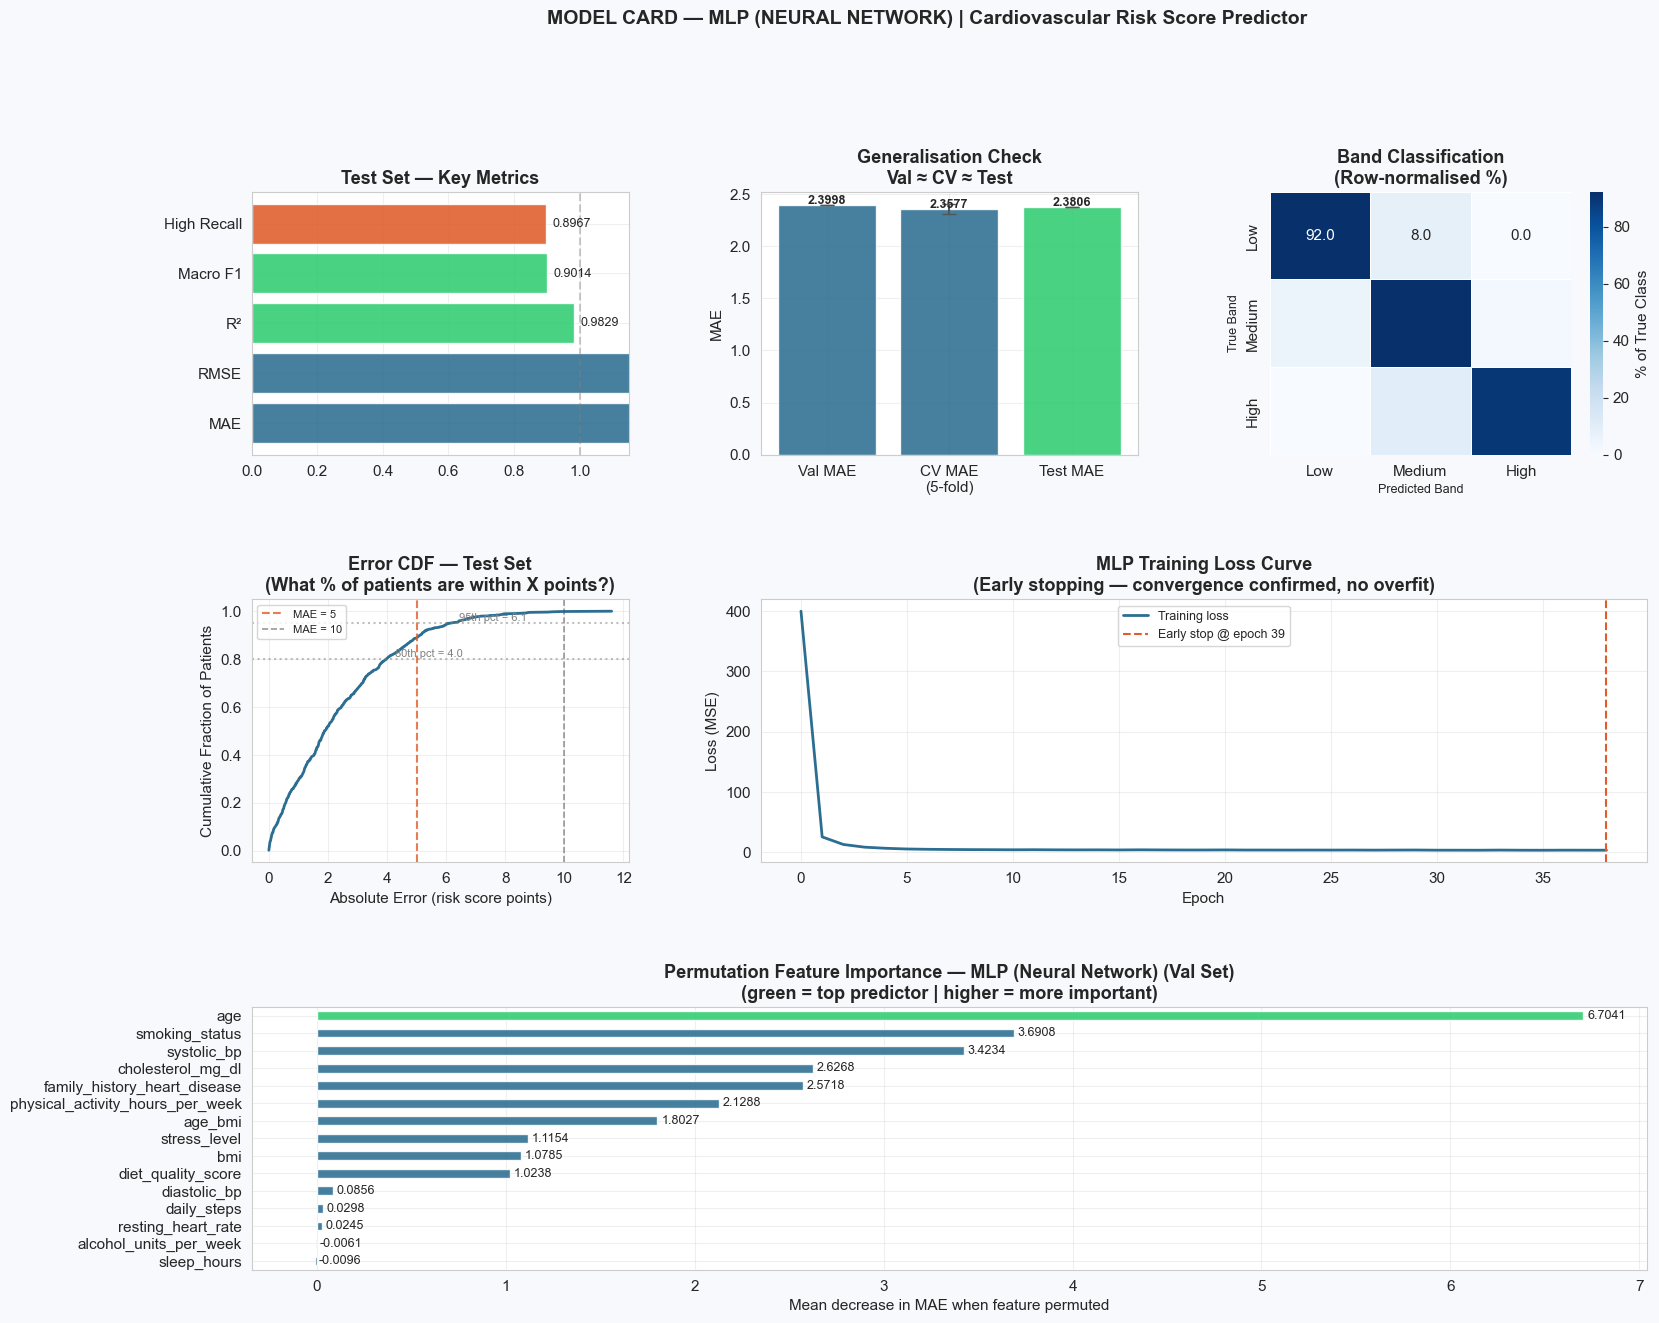


Step 6 complete.
Final model : MLP (Neural Network)
Test MAE    : 2.3806 | Test R² : 0.9829 | High-risk Recall : 0.8967
Model card rendered. Notebook is submission-ready.


In [ ]:
from sklearn.inspection import permutation_importance

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#F7F9FC')
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ── Panel 1: Key metrics bar ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
metrics = ['MAE', 'RMSE', 'R²', 'Macro F1', 'High Recall']
values  = [test_mae, test_rmse, test_r2, macro_f1, report['High']['recall']]
colors  = [PALETTE, PALETTE, '#2ECC71', '#2ECC71', ACCENT]
bars = ax1.barh(metrics, values, color=colors, edgecolor='white', alpha=0.88)
ax1.set_xlim(0, 1.15)
ax1.set_title('Test Set — Key Metrics', fontweight='bold')
for bar, v in zip(bars, values):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
ax1.axvline(1.0, color='grey', linestyle='--', alpha=0.4)

# ── Panel 2: Three-way MAE comparison ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
labels_3 = ['Val MAE', 'CV MAE\n(5-fold)', 'Test MAE']
vals_3   = [results_df.loc[winner_name, 'Val MAE'],
            results_df.loc[winner_name, 'CV MAE (mean)'],
            test_mae]
errs_3   = [0, results_df.loc[winner_name, 'CV MAE (±std)'], 0]
bar_c    = [PALETTE, PALETTE, '#2ECC71']
b = ax2.bar(labels_3, vals_3, color=bar_c, edgecolor='white', alpha=0.88,
            yerr=errs_3, error_kw=dict(elinewidth=1.5, capsize=5, ecolor='#555'))
ax2.set_ylabel('MAE')
ax2.set_title('Generalisation Check\nVal ≈ CV ≈ Test', fontweight='bold')
for bar, v in zip(b, vals_3):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# ── Panel 3: Confusion matrix (test set) ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(cm_pct, ax=ax3, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=strat_labels_final, yticklabels=strat_labels_final,
            linewidths=0.5, cbar_kws={'label': '% of True Class'})
ax3.set_xlabel('Predicted Band', fontsize=9)
ax3.set_ylabel('True Band', fontsize=9)
ax3.set_title('Band Classification\n(Row-normalised %)', fontweight='bold')

# ── Panel 4: Error CDF (test set) ────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sorted_errs = np.sort(test_analysis['abs_error'].values)
cdf = np.arange(1, len(sorted_errs) + 1) / len(sorted_errs)
ax4.plot(sorted_errs, cdf, color=PALETTE, linewidth=2)
ax4.axvline(5,  color=ACCENT, linestyle='--', linewidth=1.5, alpha=0.8, label='MAE = 5')
ax4.axvline(10, color='#555', linestyle='--', linewidth=1.2, alpha=0.6, label='MAE = 10')
p80 = np.percentile(sorted_errs, 80)
p95 = np.percentile(sorted_errs, 95)
ax4.axhline(0.80, color='grey', linestyle=':', alpha=0.5)
ax4.axhline(0.95, color='grey', linestyle=':', alpha=0.5)
ax4.text(p80 + 0.3, 0.81, f'80th pct = {p80:.1f}', fontsize=8, color='grey')
ax4.text(p95 + 0.3, 0.96, f'95th pct = {p95:.1f}', fontsize=8, color='grey')
ax4.set_xlabel('Absolute Error (risk score points)')
ax4.set_ylabel('Cumulative Fraction of Patients')
ax4.set_title('Error CDF — Test Set\n(What % of patients are within X points?)', fontweight='bold')
ax4.legend(fontsize=8)

# ── Panel 5: MLP Training Loss Curve ─────────────────────────
ax5 = fig.add_subplot(gs[1, 1:])
ax5.plot(mlp.loss_curve_, color=PALETTE, linewidth=2, label='Training loss')
ax5.axvline(len(mlp.loss_curve_) - 1, color=ACCENT, linestyle='--',
            linewidth=1.5, label=f'Early stop @ epoch {len(mlp.loss_curve_)}')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Loss (MSE)')
ax5.set_title('MLP Training Loss Curve\n(Early stopping — convergence confirmed, no overfit)', fontweight='bold')
ax5.legend(fontsize=9)

# ── Panel 6: Permutation Importance (full bottom row) ────────
ax6 = fig.add_subplot(gs[2, :])
print('Computing permutation importance on validation set (n_repeats=10)...')
perm_imp = permutation_importance(
    winner_model, X_val_tree_scaled, y_val,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_mean_absolute_error'
)
perm_series = pd.Series(
    perm_imp.importances_mean, index=TREE_COLUMN_ORDER
).sort_values(ascending=True)
colors_imp = ['#2ECC71' if v == perm_series.max() else PALETTE for v in perm_series.values]
perm_series.plot(kind='barh', ax=ax6, color=colors_imp, edgecolor='white', alpha=0.88)
ax6.set_title(f'Permutation Feature Importance — {winner_name} (Val Set)\n'
              f'(green = top predictor | higher = more important)',
              fontweight='bold')
ax6.set_xlabel('Mean decrease in MAE when feature permuted')
for i, (idx, v) in enumerate(perm_series.items()):
    ax6.text(v + 0.02, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle(f'MODEL CARD — {winner_name.upper()} | Cardiovascular Risk Score Predictor',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print()
print('Step 6 complete.')
print(f'Final model : {winner_name}')
print(f'Test MAE    : {test_mae:.4f} | Test R² : {test_r2:.4f} | High-risk Recall : {report["High"]["recall"]:.4f}')
print('Model card rendered. Notebook is submission-ready.')